In [55]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

### GET DATA

In [56]:
import os
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

def fetch_historical_data(unique_tickers, api_key, api_secret, timeframe, start_date='2020-01-01', end_date='2025-07-15'):
    """
    Fetches historical stock data for a list of tickers using the Alpaca API.

    Parameters:
        unique_tickers (list): List of tickers to fetch.
        api_key (str): Your Alpaca API key.
        api_secret (str): Your Alpaca API secret.
        start_date (str): Start date for the data (YYYY-MM-DD).
        end_date (str): End date for the data (YYYY-MM-DD).

    Returns:
        data_dict (dict): Dictionary mapping tickers to their DataFrame.
        failed_tickers (list): List of tickers that failed to fetch.
    """
    client = StockHistoricalDataClient(api_key, api_secret)

    end_date = pd.to_datetime(end_date)
    start_date = pd.to_datetime(start_date)

    data_dict = {}
    failed_tickers = []

    for ticker in unique_tickers:
        try:
            print(f"Fetching data for {ticker} from Alpaca...")
            request_params = StockBarsRequest(
                symbol_or_symbols=[ticker],
                timeframe=timeframe,
                start=start_date,
                end=end_date,
                adjustment="all"
            )
            bars = client.get_stock_bars(request_params)
            df = bars.df

            if isinstance(df.index, pd.MultiIndex):
                df = df.xs(ticker, level=0)

            df = df.reset_index()

            if df.empty:
                raise ValueError("Empty DataFrame")

            data_dict[ticker] = df

        except Exception as e:
            print(f"Failed to get data for {ticker}: {e}")
            failed_tickers.append(ticker)

    print("Fetch completed.")
    if failed_tickers:
        print("Failed tickers:", failed_tickers)

    return data_dict, failed_tickers

API_KEY = 'PKMLW0XE86NIOEV6I63V'
API_SECRET = 'aaIllPGt8RQodGb55DFeJKQoPjQuvPsYQWhrY1B7'


unique_tickers = ["QQQ"]

# 3. Fetch historical data for all unique tickers
data_dict, failed_tickers = fetch_historical_data(unique_tickers, API_KEY, API_SECRET, timeframe = TimeFrame(1, TimeFrameUnit.Minute))

Fetching data for QQQ from Alpaca...
Fetch completed.


In [57]:
# Convert timestamps to NYC time
for ticker, df in data_dict.items():
    if df['timestamp'].dt.tz is None:
        df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
    df['timestamp'] = df['timestamp'].dt.tz_convert('America/New_York')

In [58]:
qqq_data = data_dict["QQQ"]

# Filter to market hours (9:30 AM to 4:00 PM NYC time)
qqq_data = qqq_data[(qqq_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                     (qqq_data['timestamp'].dt.time <= pd.Timestamp('16:00').time())]

In [59]:
print(qqq_data.head(20))

                    timestamp    open    high     low   close     volume  \
235 2020-01-02 09:30:00-05:00  206.47  206.65  206.45  206.59  1271108.0   
236 2020-01-02 09:31:00-05:00  206.59  206.61  206.37  206.44   236985.0   
237 2020-01-02 09:32:00-05:00  206.43  206.52  206.39  206.51   202698.0   
238 2020-01-02 09:33:00-05:00  206.51  206.78  206.51  206.75   276115.0   
239 2020-01-02 09:34:00-05:00  206.75  206.91  206.75  206.82   356068.0   
240 2020-01-02 09:35:00-05:00  206.81  207.06  206.81  207.01   294139.0   
241 2020-01-02 09:36:00-05:00  207.00  207.10  206.94  207.08   159484.0   
242 2020-01-02 09:37:00-05:00  207.09  207.21  207.04  207.11   169466.0   
243 2020-01-02 09:38:00-05:00  207.12  207.16  207.01  207.09    88177.0   
244 2020-01-02 09:39:00-05:00  207.09  207.16  207.08  207.12   142848.0   
245 2020-01-02 09:40:00-05:00  207.12  207.24  207.11  207.13   142697.0   
246 2020-01-02 09:41:00-05:00  207.16  207.16  207.05  207.09    78606.0   
247 2020-01-

### BULL STRATEGY: ENTRY

# 📈 Bullish Fair Value Gap (FVG) Intraday Trading Strategy

## Strategy Overview

This strategy identifies and trades bullish Fair Value Gap (FVG) patterns on QQQ using 1-minute bars during regular market hours (9:30 AM - 4:00 PM EST).

---

## Pattern Detection Rules

### **1. Opening Range (9:30 - 9:35 AM)**

- Aggregate the first 5 minutes into a single bar
- **H0** = Opening range high
- **L0** = Opening range low

### **2. Fair Value Gap (FVG) Formation - Three Bar Pattern**

**Bar 1 (Setup):**
- Must open below H0

**Bar 2 (Expansion):**
- Must be 1.75x larger than Bar 1
- Must be bullish (close > open)
- Must gap up from Bar 1 (open > Bar 1 close)

**Bar 3 (Consolidation):**
- Must be smaller than Bar 2 (consolidation ratio < 1.0)
- Low must stay above Bar 1 high (gap maintained)
- Must close above H0 (confirms breakout)

**FVG Zone:** The gap between Bar 1 high (H1) and Bar 3 low (L3)

### **3. Retracement**

- Wait for a bearish bar (close < open)
- Bar's low must enter the FVG zone (below L3)

### **4. Entry Signal - Multi-Bar Bullish Engulfing**

- Accumulate consecutive bullish bars after retracement
- Entry triggers when accumulated bars collectively engulf the retracement bar:
  - Minimum open of bullish bars ≤ retracement close
  - Maximum close of bullish bars ≥ retracement open
- Enter at the open of the next bar

### **5. Exit Management**

**Stop Loss:** 1.0% below entry price

**Profit Target:** 1.5R (1.5 times the risk)

**Exit Priority:**
1. Stop loss hit
2. Profit target hit
3. End of day close

---

## Performance Metrics

**Backtest Results:**
================================================================================
- Total Trades: 206
- Winners: 120
- Losers: 86
- Win Rate: 58.25%
- Average Return: 0.10%
- Total Return: 20.78%

2020-01-07: FVG found at 2020-01-07 11:23:00-05:00! Range: [207.96, 208.0]
  H0: 207.94, H1: 207.96
  Retracement at 2020-01-07 11:32:00-05:00
2020-01-13: FVG found at 2020-01-13 10:16:00-05:00! Range: [211.45, 211.52]
  H0: 211.49, H1: 211.45
  Retracement at 2020-01-13 10:18:00-05:00
  LONG SIGNAL (Multi-Bar Engulfing: 5 bars) at 2020-01-13 10:25:00-05:00
  Entry: 2020-01-13 10:26:00-05:00 @ $211.58
  Stop Loss: $209.46, Target: $214.75


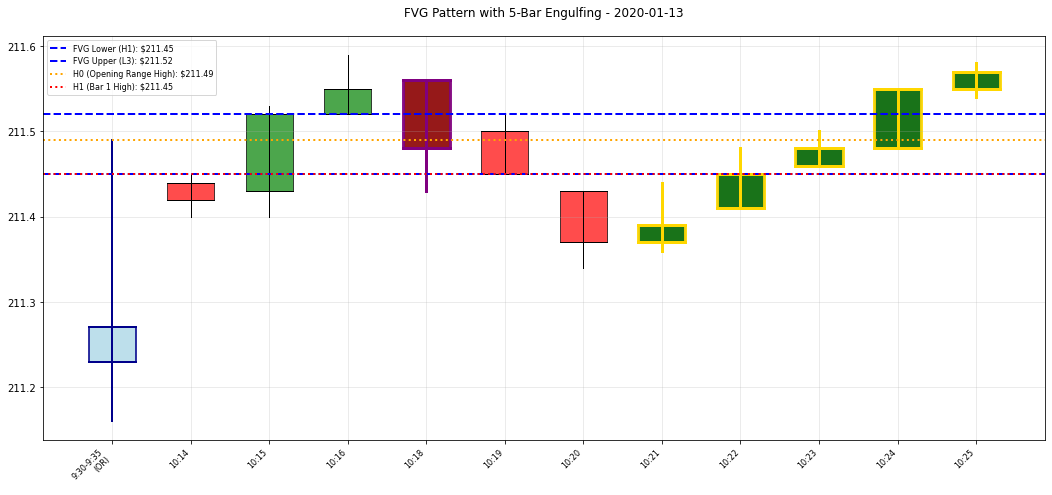

2020-01-16: FVG found at 2020-01-16 09:41:00-05:00! Range: [213.39, 213.47]
  H0: 213.42, H1: 213.39
  Retracement at 2020-01-16 09:43:00-05:00
  LONG SIGNAL (Multi-Bar Engulfing: 2 bars) at 2020-01-16 09:45:00-05:00
  Entry: 2020-01-16 09:46:00-05:00 @ $213.54
  Stop Loss: $211.40, Target: $216.74


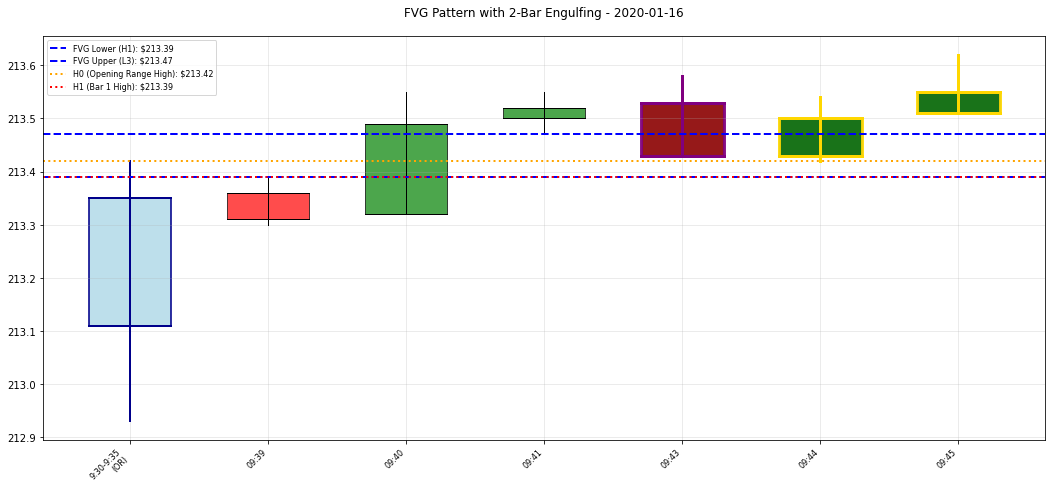

2020-01-17: FVG found at 2020-01-17 15:55:00-05:00! Range: [215.0, 215.13]
  H0: 215.08, H1: 215.00
2020-01-30: FVG found at 2020-01-30 15:00:00-05:00! Range: [213.25, 213.34]
  H0: 213.28, H1: 213.25
  Retracement at 2020-01-30 15:09:00-05:00
2020-02-06: FVG found at 2020-02-06 10:00:00-05:00! Range: [220.41, 220.63]
  H0: 220.61, H1: 220.41
  Retracement at 2020-02-06 10:03:00-05:00
  LONG SIGNAL (Multi-Bar Engulfing: 1 bars) at 2020-02-06 10:04:00-05:00
  Entry: 2020-02-06 10:05:00-05:00 @ $220.74
  Stop Loss: $218.53, Target: $224.05


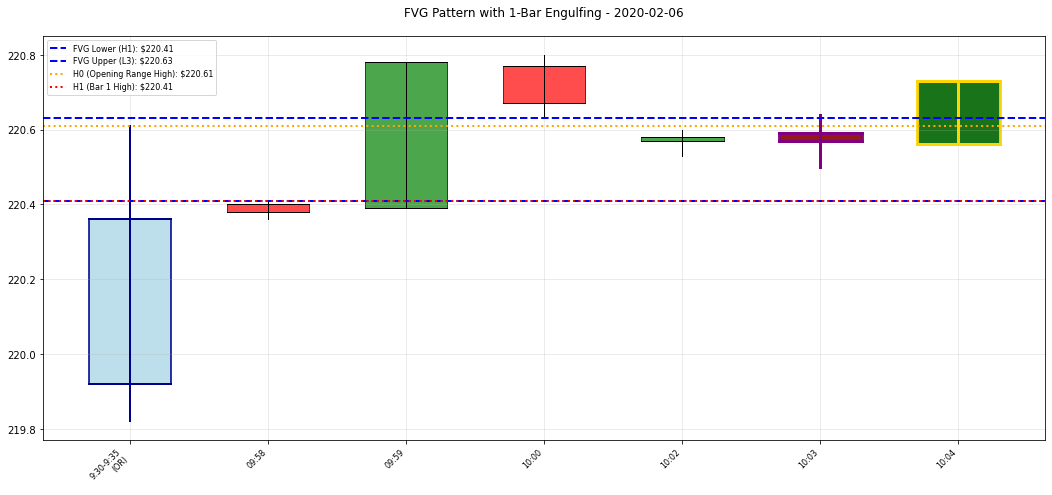

2020-02-11: FVG found at 2020-02-11 10:15:00-05:00! Range: [224.79, 224.9]
  H0: 224.74, H1: 224.79
  Retracement at 2020-02-11 10:18:00-05:00
  LONG SIGNAL (Multi-Bar Engulfing: 2 bars) at 2020-02-11 10:20:00-05:00
  Entry: 2020-02-11 10:21:00-05:00 @ $225.02
  Stop Loss: $222.77, Target: $228.40


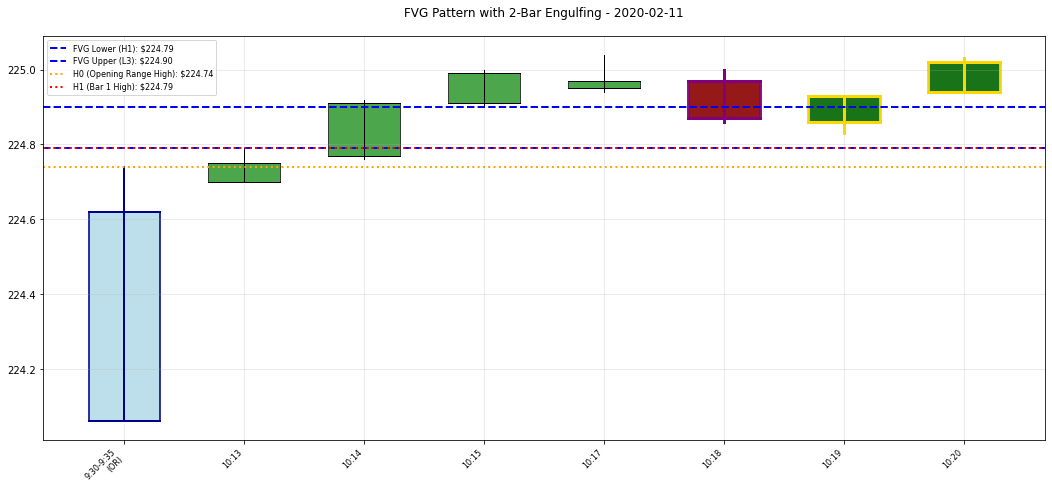

2020-02-18: FVG found at 2020-02-18 10:46:00-05:00! Range: [225.54, 225.67]
  H0: 225.54, H1: 225.54
  Retracement at 2020-02-18 10:59:00-05:00
  LONG SIGNAL (Multi-Bar Engulfing: 1 bars) at 2020-02-18 11:03:00-05:00
  Entry: 2020-02-18 11:04:00-05:00 @ $225.72
  Stop Loss: $223.46, Target: $229.11


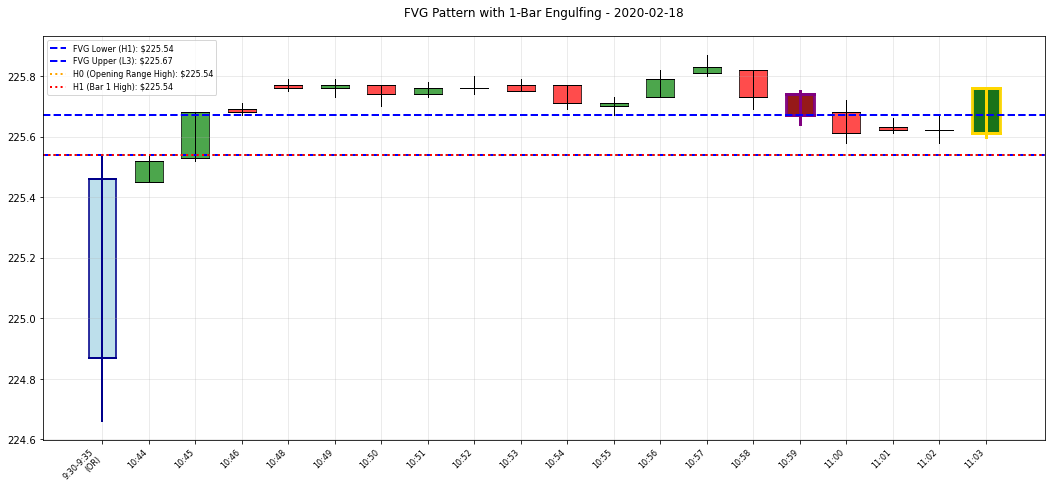


Total signals detected: 206
Total signals plotted: 5

Trades DataFrame:
           date        fvg_formation_time         fvg_complete_time  \
0    2020-01-13 2020-01-13 10:14:00-05:00 2020-01-13 10:16:00-05:00   
1    2020-01-16 2020-01-16 09:39:00-05:00 2020-01-16 09:41:00-05:00   
2    2020-02-06 2020-02-06 09:58:00-05:00 2020-02-06 10:00:00-05:00   
3    2020-02-11 2020-02-11 10:13:00-05:00 2020-02-11 10:15:00-05:00   
4    2020-02-18 2020-02-18 10:44:00-05:00 2020-02-18 10:46:00-05:00   
..          ...                       ...                       ...   
201  2025-05-23 2025-05-23 10:11:00-04:00 2025-05-23 10:13:00-04:00   
202  2025-06-05 2025-06-05 10:55:00-04:00 2025-06-05 10:57:00-04:00   
203  2025-06-06 2025-06-06 11:49:00-04:00 2025-06-06 11:51:00-04:00   
204  2025-06-10 2025-06-10 10:09:00-04:00 2025-06-10 10:11:00-04:00   
205  2025-06-17 2025-06-17 11:50:00-04:00 2025-06-17 11:52:00-04:00   

             retracement_time               signal_time  \
0   2020-01-13 

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert timestamps to NYC time
for ticker, df in data_dict.items():
    if df['timestamp'].dt.tz is None:
        df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
    df['timestamp'] = df['timestamp'].dt.tz_convert('America/New_York')

# Get QQQ data
qqq_data = data_dict['QQQ']

# Filter to market hours (9:30 AM to 4:00 PM NYC time)
qqq_data = qqq_data[(qqq_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                     (qqq_data['timestamp'].dt.time <= pd.Timestamp('16:00').time())]

# Get unique dates
dates = qqq_data['timestamp'].dt.date.unique()

signal_count = 0
plot_count = 0
max_plots = 5

# DataFrame to store trades
trades = []

for date in dates:
    # Filter data for this day
    day_data = qqq_data[qqq_data['timestamp'].dt.date == date].reset_index(drop=True)
    
    # Get first bar (9:30 to 9:35)
    first_bar_data = day_data[(day_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                               (day_data['timestamp'].dt.time <= pd.Timestamp('09:35').time())]
    
    if first_bar_data.empty:
        continue
    
    # Create 5-minute bar
    first_bar = {
        'open': first_bar_data.iloc[0]['open'],
        'high': first_bar_data['high'].max(),
        'low': first_bar_data['low'].min(),
        'close': first_bar_data.iloc[-1]['close'],
        'volume': first_bar_data['volume'].sum(),
        'trade_count': first_bar_data['trade_count'].sum(),
        'vwap': (first_bar_data['vwap'] * first_bar_data['volume']).sum() / first_bar_data['volume'].sum()
    }
    
    H0 = first_bar['high']
    L0 = first_bar['low']
    
    # Start after 9:35
    remaining_data = day_data[day_data['timestamp'].dt.time > pd.Timestamp('09:35').time()].reset_index(drop=True)
    
    # Initialize FVG variables
    expansion = False
    fvg_signal = False
    fvg_range = None
    fvg_time = None
    fvg_bars = []
    fvg_bar1_time = None  # Time of first FVG bar
    
    H1, L1, O1, C1 = None, None, None, None
    H2, L2, O2, C2 = None, None, None, None
    
    for i, row in remaining_data.iterrows():
        if not fvg_signal:
            if not expansion:
                # Looking for bar 1 or bar 2
                if H1 is None:
                    # Set bar 1
                    H1 = row['high']
                    L1 = row['low']
                    O1 = row['open']
                    C1 = row['close']
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # NEW CONDITION: O1 must be lower than H0
                    if O1 >= H0:
                        # Reset and continue looking
                        H1, L1, O1, C1 = None, None, None, None
                        continue
                else:
                    # Check if this is bar 2 (expansion + gap)
                    H2 = row['high']
                    L2 = row['low']
                    O2 = row['open']
                    C2 = row['close']
                    
                    # Prevent division by zero
                    if (H1 - L1) == 0:
                        H1, L1, O1, C1 = H2, L2, O2, C2
                        bar1_idx = i
                        bar1_time = row['timestamp']
                        
                        # NEW CONDITION: O1 must be lower than H0
                        if O1 >= H0:
                            H1, L1, O1, C1 = None, None, None, None
                        continue
                    
                    #STRONG EXPANSION
                    expansion_condition = (H2 - L2) / (H1 - L1) > 1.75 and C2>O2
                    gap_condition = O2 > C1
                    
                    if expansion_condition and gap_condition:
                        expansion = True
                        bar2_idx = i
                    else:
                        # Failed, set this bar as new bar 1
                        H1, L1, O1, C1 = H2, L2, O2, C2
                        bar1_idx = i
                        bar1_time = row['timestamp']
                        
                        # NEW CONDITION: O1 must be lower than H0
                        if O1 >= H0:
                            H1, L1, O1, C1 = None, None, None, None
            else:
                # Looking for bar 3 (consolidation + gap kept)
                H3 = row['high']
                L3 = row['low']
                C3 = row['close']
                O3 = row['open']
                
                # Prevent division by zero
                if (H2 - L2) == 0:
                    expansion = False
                    H1, L1, O1, C1 = H3, L3, row['open'], row['close']
                    H2, L2, O2, C2 = None, None, None, None
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # NEW CONDITION: O1 must be lower than H0
                    if O1 >= H0:
                        H1, L1, O1, C1 = None, None, None, None
                    continue
                
                # LOOSE CONSOLIDATION
                consolidation_condition = (H3 - L3) / (H2 - L2) < 1
                gap_kept_condition = L3 > H1
                # NEW CONDITION: C3 must be above H0 (opening range high)
                c3_above_h0_condition = C3 > H0
                
                if consolidation_condition and gap_kept_condition and c3_above_h0_condition:
                    fvg_signal = True
                    fvg_range = [H1, L3]
                    fvg_time = row['timestamp']  # Time when FVG completes (bar 3)
                    fvg_bar1_time = bar1_time  # Time of first bar of FVG
                    bar3_idx = i
                    fvg_bars = [
                        {'o': O1, 'h': H1, 'l': L1, 'c': C1, 'time': remaining_data.iloc[bar1_idx]['timestamp']},
                        {'o': O2, 'h': H2, 'l': L2, 'c': C2, 'time': remaining_data.iloc[bar2_idx]['timestamp']},
                        {'o': row['open'], 'h': H3, 'l': L3, 'c': C3, 'time': row['timestamp']}
                    ]
                    if plot_count < max_plots:
                        print(f"{date}: FVG found at {fvg_time}! Range: {fvg_range}")
                        print(f"  H0: {H0:.2f}, H1: {H1:.2f}")
                    
                else:
                    # Failed, reset and set this bar as new bar 1
                    expansion = False
                    H1, L1, O1, C1 = H3, L3, row['open'], row['close']
                    H2, L2, O2, C2 = None, None, None, None
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # NEW CONDITION: O1 must be lower than H0
                    if O1 >= H0:
                        H1, L1, O1, C1 = None, None, None, None
        else:
            # FVG found, now looking for retracement
            retracement = False
            retracement_bar = None
            retracement_idx = None
            bars_after_fvg = []
            
            for j in range(i+1, len(remaining_data)):
                bar = remaining_data.iloc[j]
                bars_after_fvg.append(bar)
                
                if not retracement:
                    # Looking for bearish bar entering FVG zone
                    is_bearish = bar['close'] < bar['open']
                    enters_fvg = bar['low'] < fvg_range[1]
                    
                    if is_bearish and enters_fvg:
                        retracement = True
                        retracement_idx = len(bars_after_fvg) - 1  # Index within bars_after_fvg
                        retracement_bar = {
                            'o': bar['open'],
                            'h': bar['high'],
                            'l': bar['low'],
                            'c': bar['close'],
                            'time': bar['timestamp']
                        }
                        # Initialize bullish bars accumulator
                        bullish_bars = []
                        if plot_count < max_plots:
                            print(f"  Retracement at {retracement_bar['time']}")
                else:
                    # Looking for multi-bar bullish engulfing
                    is_bullish = bar['close'] > bar['open']
                    
                    if is_bullish:
                        # Add to our bullish bar accumulator
                        bullish_bars.append({
                            'open': bar['open'],
                            'close': bar['close'],
                            'high': bar['high'],
                            'low': bar['low'],
                            'time': bar['timestamp']
                        })
                        
                        # Check multi-bar engulfing condition
                        min_open = min(b['open'] for b in bullish_bars)
                        max_close = max(b['close'] for b in bullish_bars)
                        
                        # Engulfing condition: min_open <= retracement_close AND max_close >= retracement_open
                        engulfs = (min_open <= retracement_bar['c']) and (max_close >= retracement_bar['o'])
                    else:
                        # Non-bullish bar: reset accumulator and keep looking
                        bullish_bars = []
                        engulfs = False
                    
                    if engulfs:
                        signal_time = bar['timestamp']
                        signal_idx = len(bars_after_fvg) - 1  # Index within bars_after_fvg
                        num_engulfing_bars = len(bullish_bars)
                        
                        # Entry is next bar
                        if j + 1 < len(remaining_data):
                            entry_bar = remaining_data.iloc[j + 1]
                            entry_time = entry_bar['timestamp']
                            entry_price = entry_bar['open']
                            stop_loss = entry_price * 0.99  # Fixed 1.0% stop loss
                            risk = entry_price - stop_loss
                            profit_target = entry_price + (1.5 * risk)  # 1.5R profit target
                            
                            # Store trade with retracement and signal times
                            trades.append({
                                'date': date,
                                'fvg_formation_time': fvg_bar1_time,
                                'fvg_complete_time': fvg_time,
                                'retracement_time': retracement_bar['time'],
                                'signal_time': signal_time,
                                'entry_time': entry_time,
                                'entry_price': entry_price,
                                'stop_loss': stop_loss,
                                'profit_target': profit_target,
                                'risk': risk,
                                'fvg_range': fvg_range,
                                'H0': H0,
                                'H1': H1,
                                'num_engulfing_bars': num_engulfing_bars
                            })
                            
                            if plot_count < max_plots:
                                print(f"  LONG SIGNAL (Multi-Bar Engulfing: {num_engulfing_bars} bars) at {signal_time}")
                                print(f"  Entry: {entry_time} @ ${entry_price:.2f}")
                                print(f"  Stop Loss: ${stop_loss:.2f}, Target: ${profit_target:.2f}")
                            
                            signal_count += 1
                            
                            # Only plot first max_plots signals
                            if plot_count < max_plots:
                                # Create opening range bar for reference
                                opening_bar = {
                                    'o': first_bar['open'],
                                    'h': first_bar['high'],
                                    'l': first_bar['low'],
                                    'c': first_bar['close'],
                                    'time': pd.Timestamp('09:30').time()  # Label it as 9:30
                                }
                                
                                # Plot Opening bar + FVG bars + all bars until signal
                                all_bars = [opening_bar] + fvg_bars + [{'o': b['open'], 'h': b['high'], 'l': b['low'], 
                                                        'c': b['close'], 'time': b['timestamp']} 
                                                       for b in bars_after_fvg[:j-i+1]]
                                
                                # Adjust indices to match all_bars array (add 1 for opening bar offset)
                                retracement_plot_idx = 1 + 3 + retracement_idx  # 1 opening bar + 3 FVG bars + position in bars_after_fvg
                                signal_plot_idx = 1 + 3 + signal_idx  # 1 opening bar + 3 FVG bars + position in bars_after_fvg
                                
                                # Calculate engulfing bars indices (the last num_engulfing_bars before signal)
                                engulfing_start_idx = signal_plot_idx - num_engulfing_bars + 1
                                engulfing_indices = list(range(engulfing_start_idx, signal_plot_idx + 1))
                                
                                fig, ax = plt.subplots(figsize=(16, 7))
                                for k, bar_data in enumerate(all_bars):
                                    # Determine special highlighting
                                    if k == 0:
                                        # Opening range bar - highlight with special color
                                        color = 'lightblue'
                                        edgecolor = 'darkblue'
                                        linewidth = 2
                                        alpha = 0.8
                                    elif k == retracement_plot_idx:
                                        # Retracement bar - highlight with thick border and special color
                                        color = 'darkred'
                                        edgecolor = 'purple'
                                        linewidth = 3
                                        alpha = 0.9
                                    elif k in engulfing_indices:
                                        # Multi-bar engulfing bars - highlight differently
                                        color = 'darkgreen'
                                        edgecolor = 'gold'
                                        linewidth = 3
                                        alpha = 0.9
                                    else:
                                        # Normal bars
                                        color = 'green' if bar_data['c'] >= bar_data['o'] else 'red'
                                        edgecolor = 'black'
                                        linewidth = 1
                                        alpha = 0.7
                                    
                                    # Draw candlestick
                                    ax.plot([k, k], [bar_data['l'], bar_data['h']], color=edgecolor, linewidth=linewidth)
                                    ax.plot([k-0.3, k+0.3], [bar_data['o'], bar_data['o']], color=edgecolor, linewidth=linewidth)
                                    ax.plot([k-0.3, k+0.3], [bar_data['c'], bar_data['c']], color=edgecolor, linewidth=linewidth)
                                    ax.add_patch(plt.Rectangle((k-0.3, min(bar_data['o'], bar_data['c'])), 0.6, 
                                                               abs(bar_data['c']-bar_data['o']), 
                                                               facecolor=color, edgecolor=edgecolor, 
                                                               linewidth=linewidth, alpha=alpha))
                                
                                # FVG zone
                                ax.axhline(y=fvg_range[0], color='blue', linestyle='--', linewidth=2, 
                                          label=f'FVG Lower (H1): ${fvg_range[0]:.2f}')
                                ax.axhline(y=fvg_range[1], color='blue', linestyle='--', linewidth=2, 
                                          label=f'FVG Upper (L3): ${fvg_range[1]:.2f}')
                                
                                # H0 and H1 lines
                                ax.axhline(y=H0, color='orange', linestyle=':', linewidth=2, 
                                          label=f'H0 (Opening Range High): ${H0:.2f}')
                                ax.axhline(y=H1, color='red', linestyle=':', linewidth=2, 
                                          label=f'H1 (Bar 1 High): ${H1:.2f}')
                                
                                ax.set_xticks(range(len(all_bars)))
                                # Format time labels, special handling for opening bar
                                time_labels = []
                                for k, b in enumerate(all_bars):
                                    if k == 0:
                                        time_labels.append('9:30-9:35\n(OR)')
                                    else:
                                        time_labels.append(b['time'].strftime('%H:%M'))
                                ax.set_xticklabels(time_labels, rotation=45, ha='right', fontsize=8)
                                ax.set_title(f'FVG Pattern with {num_engulfing_bars}-Bar Engulfing - {date}', fontsize=12, pad=20)
                                ax.legend(loc='upper left', fontsize=8)
                                ax.grid(True, alpha=0.3)
                                
                                # Add some padding to prevent cutoff
                                plt.subplots_adjust(bottom=0.12, top=0.92, left=0.08, right=0.95)
                                plt.show()
                                
                                plot_count += 1
                        break
            
            break

trades_df = pd.DataFrame(trades)
print(f"\nTotal signals detected: {signal_count}")
print(f"Total signals plotted: {plot_count}")
print("\nTrades DataFrame:")
print(trades_df)


Trade 1 - 2020-01-13
FVG Formation: 2020-01-13 10:14:00-05:00
Signal: 2020-01-13 10:25:00-05:00
Entry: 2020-01-13 10:26:00-05:00 @ $211.58
Exit: 2020-01-13 16:00:00-05:00 @ $212.76 (End of Day)
Return: 0.56%


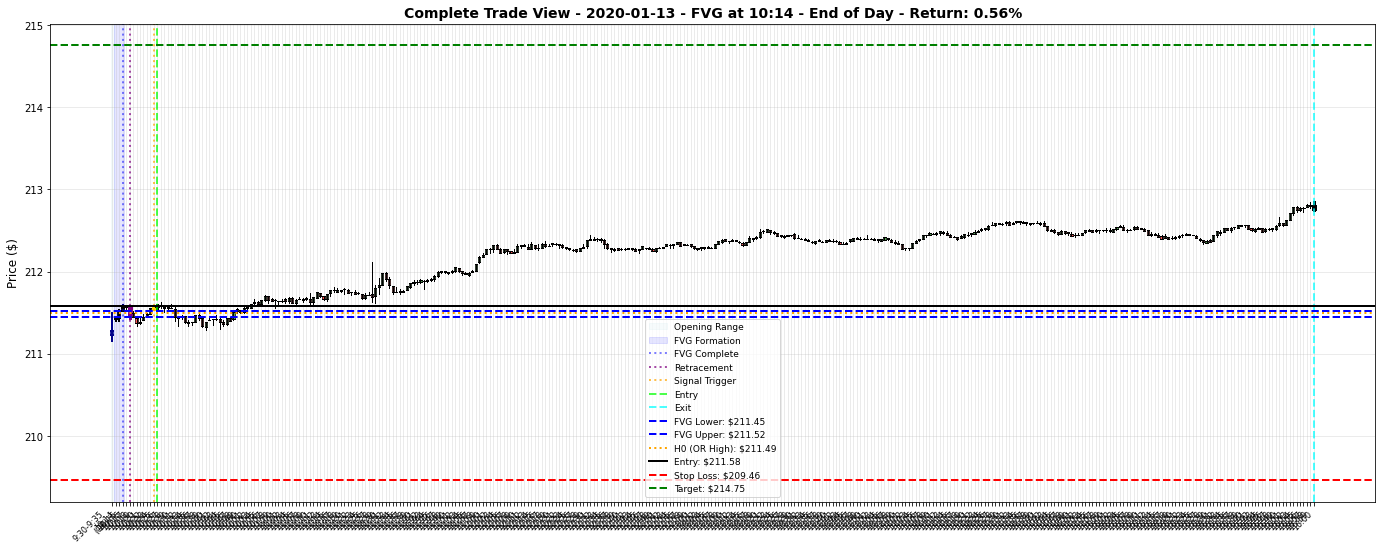


Trade 2 - 2020-01-16
FVG Formation: 2020-01-16 09:39:00-05:00
Signal: 2020-01-16 09:45:00-05:00
Entry: 2020-01-16 09:46:00-05:00 @ $213.54
Exit: 2020-01-16 16:00:00-05:00 @ $214.02 (End of Day)
Return: 0.22%


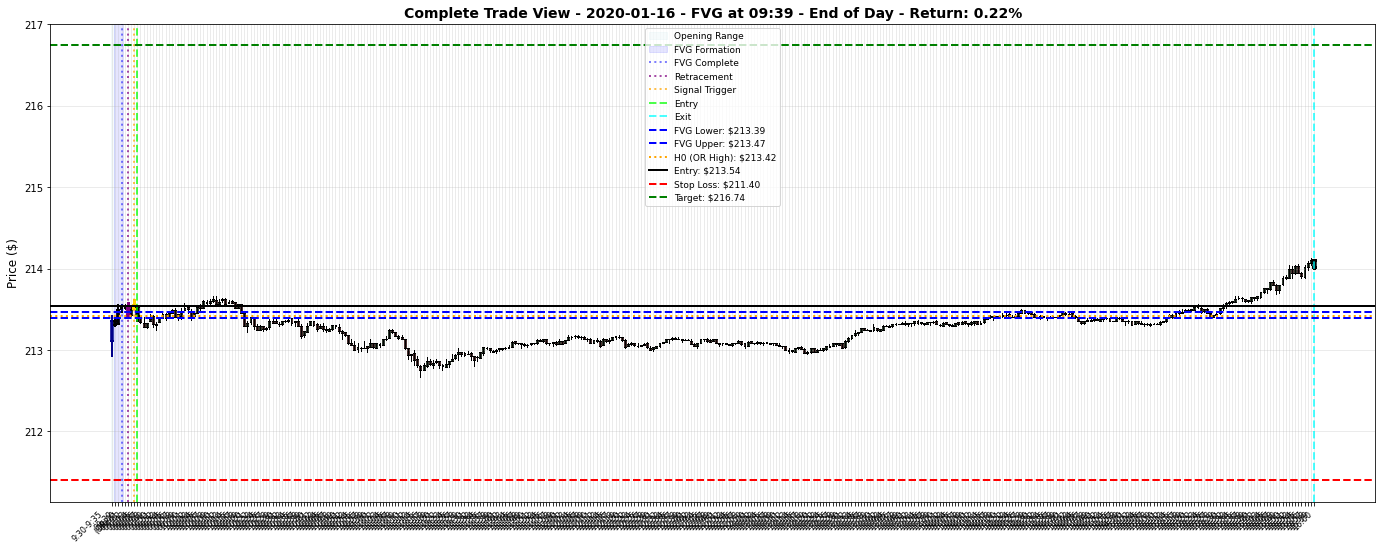


Trade 3 - 2020-02-06
FVG Formation: 2020-02-06 09:58:00-05:00
Signal: 2020-02-06 10:04:00-05:00
Entry: 2020-02-06 10:05:00-05:00 @ $220.74
Exit: 2020-02-06 16:00:00-05:00 @ $221.68 (End of Day)
Return: 0.43%


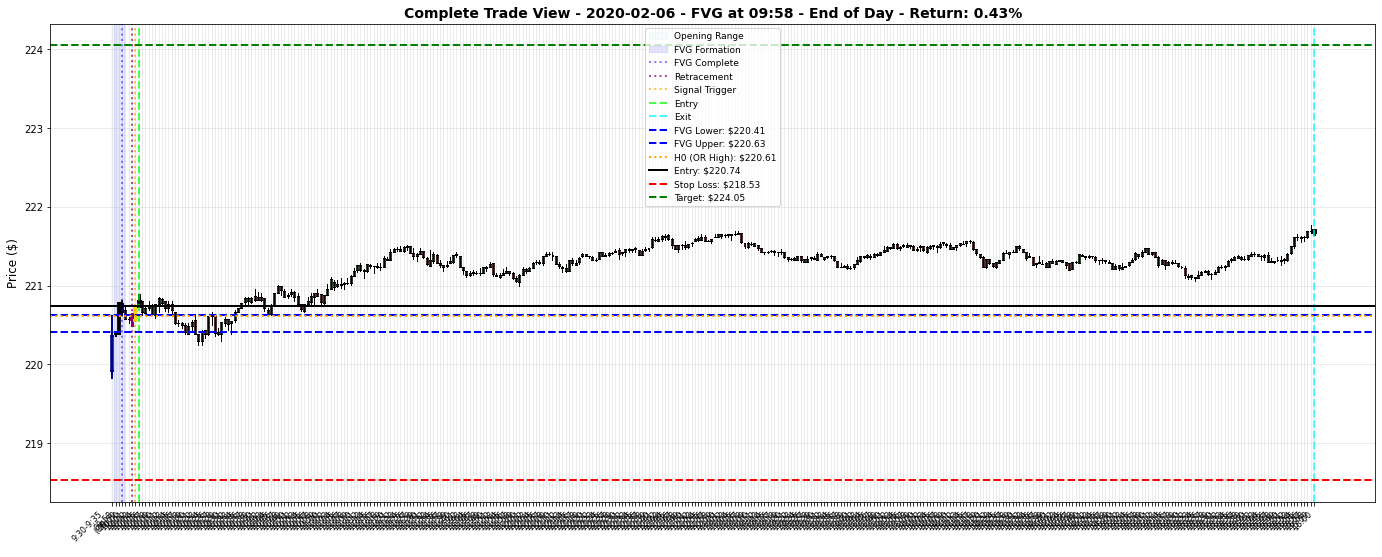


Trade 4 - 2020-02-11
FVG Formation: 2020-02-11 10:13:00-05:00
Signal: 2020-02-11 10:20:00-05:00
Entry: 2020-02-11 10:21:00-05:00 @ $225.02
Exit: 2020-02-11 16:00:00-05:00 @ $223.49 (End of Day)
Return: -0.68%


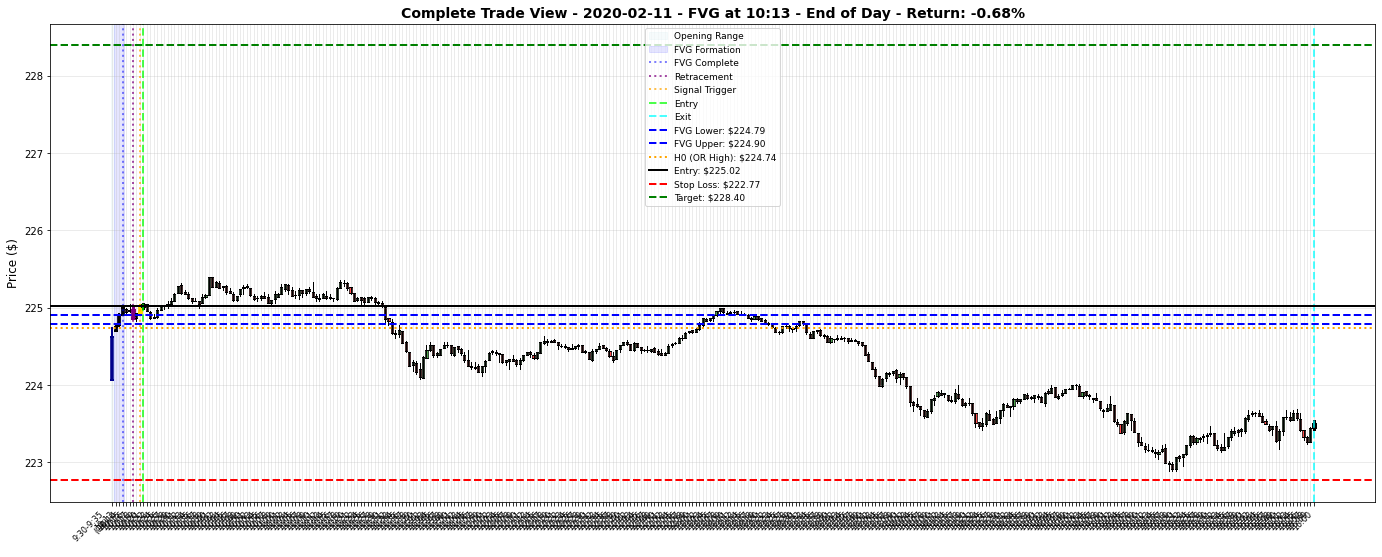


Trade 5 - 2020-02-18
FVG Formation: 2020-02-18 10:44:00-05:00
Signal: 2020-02-18 11:03:00-05:00
Entry: 2020-02-18 11:04:00-05:00 @ $225.72
Exit: 2020-02-18 16:00:00-05:00 @ $226.13 (End of Day)
Return: 0.18%


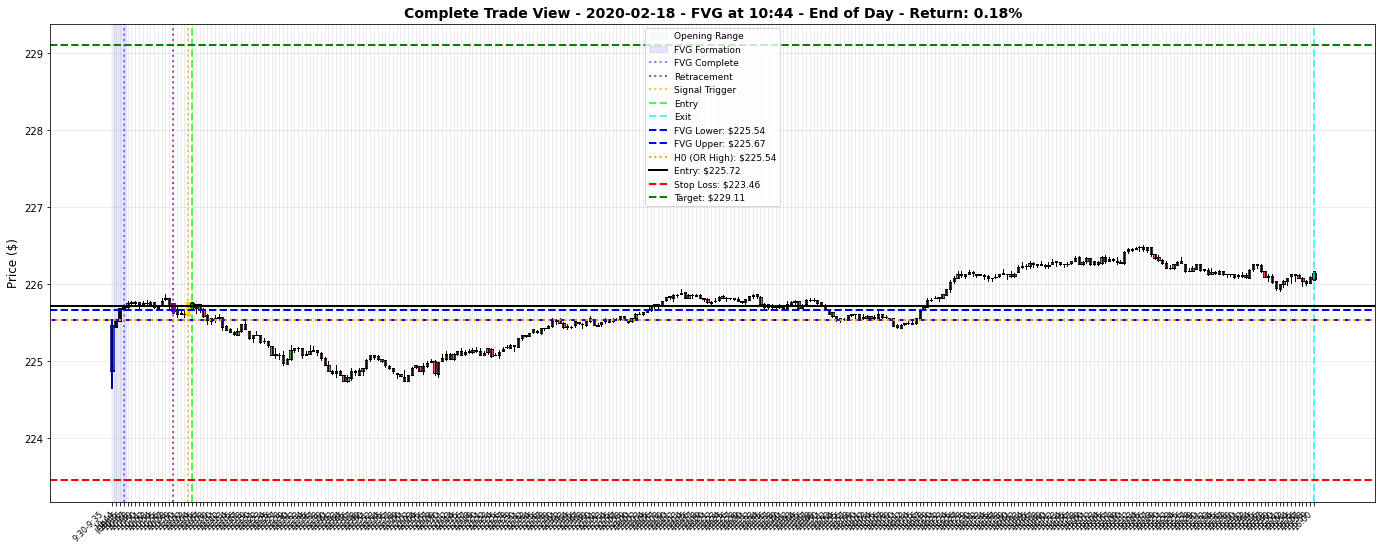


TRADE RESULTS SUMMARY
           date        fvg_formation_time               signal_time  \
0    2020-01-13 2020-01-13 10:14:00-05:00 2020-01-13 10:25:00-05:00   
1    2020-01-16 2020-01-16 09:39:00-05:00 2020-01-16 09:45:00-05:00   
2    2020-02-06 2020-02-06 09:58:00-05:00 2020-02-06 10:04:00-05:00   
3    2020-02-11 2020-02-11 10:13:00-05:00 2020-02-11 10:20:00-05:00   
4    2020-02-18 2020-02-18 10:44:00-05:00 2020-02-18 11:03:00-05:00   
..          ...                       ...                       ...   
201  2025-05-23 2025-05-23 10:11:00-04:00 2025-05-23 10:24:00-04:00   
202  2025-06-05 2025-06-05 10:55:00-04:00 2025-06-05 11:09:00-04:00   
203  2025-06-06 2025-06-06 11:49:00-04:00 2025-06-06 12:10:00-04:00   
204  2025-06-10 2025-06-10 10:09:00-04:00 2025-06-10 10:15:00-04:00   
205  2025-06-17 2025-06-17 11:50:00-04:00 2025-06-17 12:03:00-04:00   

                   entry_time  entry_price                 exit_time  \
0   2020-01-13 10:26:00-05:00       211.58 2020-01-1

In [61]:
# Execute trades and analyze results with combined plots
results = []
plot_count = 0
max_plots = 5

for idx, trade in trades_df.iterrows():
    date = trade['date']
    fvg_formation_time = trade['fvg_formation_time']
    fvg_complete_time = trade['fvg_complete_time']
    retracement_time = trade['retracement_time']
    signal_time = trade['signal_time']
    entry_time = trade['entry_time']
    entry_price = trade['entry_price']
    stop_loss = trade['stop_loss']
    profit_target = trade['profit_target']
    fvg_range = trade['fvg_range']
    H0 = trade['H0']
    L0 = trade['L0'] if 'L0' in trade else None  # Get L0 if available
    
    # Get data from entry time onwards
    day_data = qqq_data[qqq_data['timestamp'].dt.date == date].reset_index(drop=True)
    entry_idx = day_data[day_data['timestamp'] == entry_time].index[0]
    trade_data = day_data.iloc[entry_idx:].reset_index(drop=True)
    
    # Track trade
    exit_time = None
    exit_price = None
    exit_reason = None
    
    trade_bars = []
    
    for i, bar in trade_data.iterrows():
        trade_bars.append(bar)
        
        # Check stop loss
        if bar['low'] <= stop_loss:
            exit_time = bar['timestamp']
            exit_price = stop_loss
            exit_reason = 'Stop Loss'
            break
        
        # Check profit target
        if bar['high'] >= profit_target:
            exit_time = bar['timestamp']
            exit_price = profit_target
            exit_reason = 'Profit Target'
            break
    
    # If no exit, close at end of day
    if exit_time is None:
        exit_time = trade_data.iloc[-1]['timestamp']
        exit_price = trade_data.iloc[-1]['close']
        exit_reason = 'End of Day'
    
    # Calculate returns
    pct_return = ((exit_price - entry_price) / entry_price) * 100
    
    # Store result
    results.append({
        'date': date,
        'fvg_formation_time': fvg_formation_time,
        'signal_time': signal_time,
        'entry_time': entry_time,
        'entry_price': entry_price,
        'exit_time': exit_time,
        'exit_price': exit_price,
        'exit_reason': exit_reason,
        'pct_return': pct_return,
        'stop_loss': stop_loss,
        'profit_target': profit_target
    })
    
    if plot_count < max_plots:
        print(f"\nTrade {idx + 1} - {date}")
        print(f"FVG Formation: {fvg_formation_time}")
        print(f"Signal: {signal_time}")
        print(f"Entry: {entry_time} @ ${entry_price:.2f}")
        print(f"Exit: {exit_time} @ ${exit_price:.2f} ({exit_reason})")
        print(f"Return: {pct_return:.2f}%")
    
    # Only plot first max_plots trades
    if plot_count < max_plots:
        # Get opening range bar for this date
        first_bar_data = day_data[(day_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                                   (day_data['timestamp'].dt.time <= pd.Timestamp('09:35').time())]
        
        if not first_bar_data.empty:
            opening_bar = pd.Series({
                'timestamp': pd.Timestamp(f"{date} 09:30:00").tz_localize('America/New_York'),
                'open': first_bar_data.iloc[0]['open'],
                'high': first_bar_data['high'].max(),
                'low': first_bar_data['low'].min(),
                'close': first_bar_data.iloc[-1]['close']
            })
        
        # Get all bars from FVG formation to trade exit
        full_trade_data = day_data[(day_data['timestamp'] >= fvg_formation_time) & 
                                   (day_data['timestamp'] <= exit_time)].reset_index(drop=True)
        
        # Insert opening bar at the beginning
        if not first_bar_data.empty:
            full_trade_data = pd.concat([pd.DataFrame([opening_bar]), full_trade_data], ignore_index=True)
        
        # Find special bar indices (add 1 offset for opening bar)
        fvg_complete_idx = None
        retracement_idx = None
        signal_idx = None
        entry_bar_idx = None
        exit_bar_idx = None
        
        for i, bar in full_trade_data.iterrows():
            if i == 0:  # Skip opening bar
                continue
            if bar['timestamp'] == fvg_complete_time:
                fvg_complete_idx = i
            if bar['timestamp'] == retracement_time:
                retracement_idx = i
            if bar['timestamp'] == signal_time:
                signal_idx = i
            if bar['timestamp'] == entry_time:
                entry_bar_idx = i
            if bar['timestamp'] == exit_time:
                exit_bar_idx = i
        
        # Plot complete trade view
        fig, ax = plt.subplots(figsize=(20, 8))
        
        for k, bar in full_trade_data.iterrows():
            # Default styling
            color = 'green' if bar['close'] >= bar['open'] else 'red'
            alpha = 0.7
            linewidth = 1
            edgecolor = 'black'
            
            # Highlight opening range bar
            if k == 0:
                color = 'lightblue'
                edgecolor = 'darkblue'
                linewidth = 2
                alpha = 0.8
            
            # Highlight FVG formation bars (bars 1-3, now indices 1-3 due to opening bar)
            elif k >= 1 and k <= 3:
                alpha = 0.9
                linewidth = 2
            
            # Highlight retracement bar
            elif k == retracement_idx:
                color = 'darkred'
                edgecolor = 'purple'
                linewidth = 3
                alpha = 0.9
            
            # Highlight signal bar (bullish engulfing)
            elif k == signal_idx:
                color = 'darkgreen'
                edgecolor = 'gold'
                linewidth = 3
                alpha = 0.9
            
            # Highlight entry bar
            elif k == entry_bar_idx:
                linewidth = 3
                color = 'lime' if bar['close'] >= bar['open'] else 'red'
            
            # Highlight exit bar
            elif k == exit_bar_idx:
                linewidth = 3
                color = 'cyan' if bar['close'] >= bar['open'] else 'purple'
            
            ax.plot([k, k], [bar['low'], bar['high']], color=edgecolor, linewidth=linewidth)
            ax.plot([k-0.3, k+0.3], [bar['open'], bar['open']], color=edgecolor, linewidth=linewidth)
            ax.plot([k-0.3, k+0.3], [bar['close'], bar['close']], color=edgecolor, linewidth=linewidth)
            ax.add_patch(plt.Rectangle((k-0.3, min(bar['open'], bar['close'])), 0.6, 
                                       abs(bar['close']-bar['open']), facecolor=color, 
                                       edgecolor=edgecolor, linewidth=linewidth, alpha=alpha))
        
        # Mark opening range
        ax.axvspan(-0.5, 0.5, alpha=0.1, color='lightblue', label='Opening Range')
        
        # Mark FVG formation zone (adjusted for opening bar offset)
        ax.axvspan(0.5, 3.5, alpha=0.1, color='blue', label='FVG Formation')
        
        # Mark FVG completion
        if fvg_complete_idx is not None:
            ax.axvline(x=fvg_complete_idx, color='blue', linestyle=':', linewidth=2, alpha=0.5, label='FVG Complete')
        
        # Mark retracement
        if retracement_idx is not None:
            ax.axvline(x=retracement_idx, color='purple', linestyle=':', linewidth=2, alpha=0.7, label='Retracement')
        
        # Mark signal and entry with vertical lines
        if signal_idx is not None:
            ax.axvline(x=signal_idx, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Signal Trigger')
        if entry_bar_idx is not None:
            ax.axvline(x=entry_bar_idx, color='lime', linestyle='--', linewidth=2, alpha=0.7, label='Entry')
        if exit_bar_idx is not None:
            ax.axvline(x=exit_bar_idx, color='cyan', linestyle='--', linewidth=2, alpha=0.7, label='Exit')
        
        # Add horizontal lines
        ax.axhline(y=fvg_range[0], color='blue', linestyle='--', linewidth=2, label=f'FVG Lower: ${fvg_range[0]:.2f}')
        ax.axhline(y=fvg_range[1], color='blue', linestyle='--', linewidth=2, label=f'FVG Upper: ${fvg_range[1]:.2f}')
        ax.axhline(y=H0, color='orange', linestyle=':', linewidth=2, label=f'H0 (OR High): ${H0:.2f}')
        if L0 is not None:
            ax.axhline(y=L0, color='brown', linestyle=':', linewidth=2, label=f'L0 (OR Low): ${L0:.2f}')
        ax.axhline(y=entry_price, color='black', linestyle='-', linewidth=2, label=f'Entry: ${entry_price:.2f}')
        ax.axhline(y=stop_loss, color='red', linestyle='--', linewidth=2, label=f'Stop Loss: ${stop_loss:.2f}')
        ax.axhline(y=profit_target, color='green', linestyle='--', linewidth=2, label=f'Target: ${profit_target:.2f}')
        
        ax.set_xticks(range(len(full_trade_data)))
        # Format time labels with special handling for opening bar
        time_labels = []
        for k, bar in full_trade_data.iterrows():
            if k == 0:
                time_labels.append('9:30-9:35\n(OR)')
            else:
                time_labels.append(bar['timestamp'].strftime('%H:%M'))
        ax.set_xticklabels(time_labels, rotation=45, ha='right', fontsize=8)
        
        ax.set_title(f'Complete Trade View - {date} - FVG at {fvg_formation_time.strftime("%H:%M")} - {exit_reason} - Return: {pct_return:.2f}%', 
                     fontsize=14, fontweight='bold')
        ax.set_ylabel('Price ($)', fontsize=12)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.subplots_adjust(bottom=0.12, top=0.95, left=0.06, right=0.98)
        plt.show()
        
        plot_count += 1

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("TRADE RESULTS SUMMARY")
print("="*80)
print(results_df)
print("\n" + "="*80)
print(f"Total Trades: {len(results_df)}")
print(f"Winners: {len(results_df[results_df['pct_return'] > 0])}")
print(f"Losers: {len(results_df[results_df['pct_return'] < 0])}")
if len(results_df) > 0:
    print(f"Win Rate: {(len(results_df[results_df['pct_return'] > 0]) / len(results_df) * 100):.2f}%")
    print(f"Average Return: {results_df['pct_return'].mean():.2f}%")
    print(f"Total Return: {results_df['pct_return'].sum():.2f}%")
print("="*80)

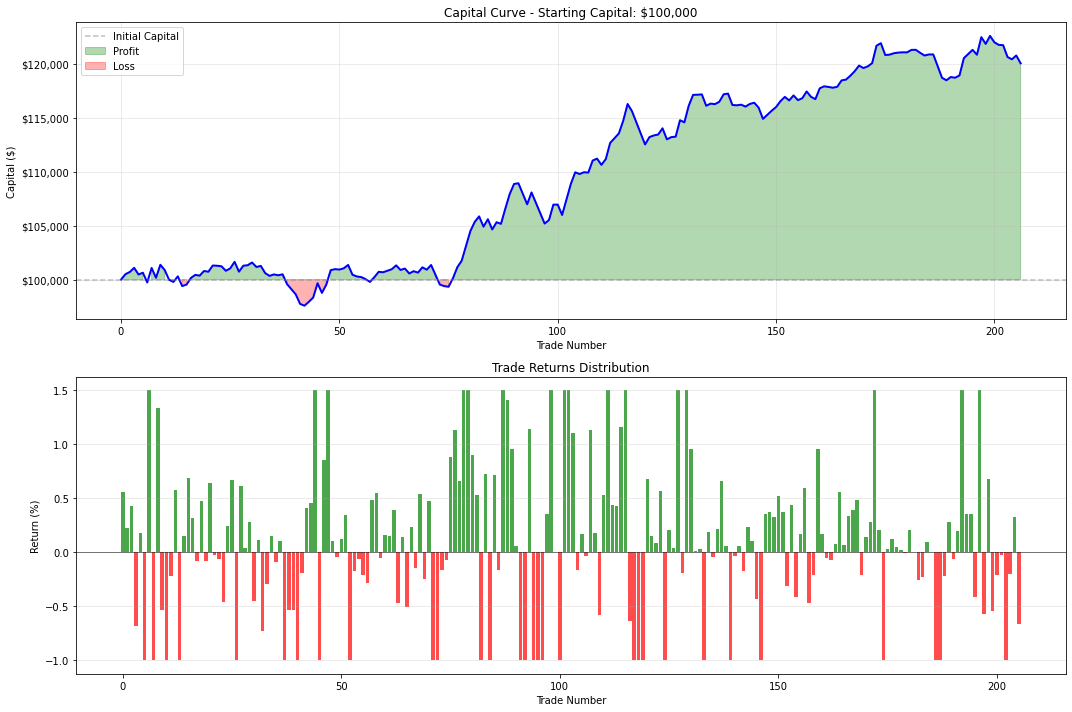


ENHANCED BACKTEST RESULTS
Initial Capital:        $100,000.00
Final Capital:          $120,078.90
Total P&L:              $20,078.90
Total Return:           20.08%
Allocation per Trade:   90%
--------------------------------------------------------------------------------
Total Trades:           206
Winning Trades:         120 (58.3%)
Losing Trades:          86 (41.7%)
Win Rate:               58.25%
--------------------------------------------------------------------------------
Average Return:         0.10%
Average Win:            0.55%
Average Loss:           -0.52%
Profit Factor:          1.46
Max Drawdown:           4.01%
Best Trade:             1.50%
Worst Trade:            -1.00%


In [62]:
# Backtest with capital allocation
initial_capital = 100000
allocation = 0.90  # 90% of capital per trade
capital = initial_capital
capital_history = [initial_capital]
trade_returns = []

for idx, row in results_df.iterrows():
    trade_capital = capital * allocation
    pct_return = row['pct_return'] / 100
    pnl = trade_capital * pct_return
    capital += pnl
    capital_history.append(capital)
    trade_returns.append(pct_return)

# Plot capital curve
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Capital curve
ax1.plot(range(len(capital_history)), capital_history, linewidth=2, color='blue')
ax1.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.fill_between(range(len(capital_history)), initial_capital, capital_history, 
                  where=[c >= initial_capital for c in capital_history], 
                  alpha=0.3, color='green', label='Profit')
ax1.fill_between(range(len(capital_history)), initial_capital, capital_history, 
                  where=[c < initial_capital for c in capital_history], 
                  alpha=0.3, color='red', label='Loss')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Capital ($)')
ax1.set_title(f'Capital Curve - Starting Capital: ${initial_capital:,.0f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Trade returns distribution
ax2.bar(range(len(results_df)), results_df['pct_return'], 
        color=['green' if x > 0 else 'red' for x in results_df['pct_return']], alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Trade Number')
ax2.set_ylabel('Return (%)')
ax2.set_title('Trade Returns Distribution')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Enhanced statistics
final_capital = capital_history[-1]
total_pnl = final_capital - initial_capital
total_return_pct = ((final_capital - initial_capital) / initial_capital) * 100

winning_trades = results_df[results_df['pct_return'] > 0]
losing_trades = results_df[results_df['pct_return'] < 0]

avg_win = winning_trades['pct_return'].mean() if len(winning_trades) > 0 else 0
avg_loss = losing_trades['pct_return'].mean() if len(losing_trades) > 0 else 0

# Calculate max drawdown
peak = initial_capital
max_dd = 0
for cap in capital_history:
    if cap > peak:
        peak = cap
    dd = ((peak - cap) / peak) * 100
    if dd > max_dd:
        max_dd = dd

print("\n" + "="*80)
print("ENHANCED BACKTEST RESULTS")
print("="*80)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Capital:          ${final_capital:,.2f}")
print(f"Total P&L:              ${total_pnl:,.2f}")
print(f"Total Return:           {total_return_pct:.2f}%")
print(f"Allocation per Trade:   {allocation*100:.0f}%")
print("-"*80)
print(f"Total Trades:           {len(results_df)}")
print(f"Winning Trades:         {len(winning_trades)} ({len(winning_trades)/len(results_df)*100:.1f}%)")
print(f"Losing Trades:          {len(losing_trades)} ({len(losing_trades)/len(results_df)*100:.1f}%)")
print(f"Win Rate:               {(len(winning_trades) / len(results_df) * 100):.2f}%")
print("-"*80)
print(f"Average Return:         {results_df['pct_return'].mean():.2f}%")
print(f"Average Win:            {avg_win:.2f}%")
print(f"Average Loss:           {avg_loss:.2f}%")
print(f"Profit Factor:          {abs(winning_trades['pct_return'].sum() / losing_trades['pct_return'].sum()):.2f}" if len(losing_trades) > 0 else "N/A")
print(f"Max Drawdown:           {max_dd:.2f}%")
print(f"Best Trade:             {results_df['pct_return'].max():.2f}%")
print(f"Worst Trade:            {results_df['pct_return'].min():.2f}%")
print("="*80)

### BEAR CASE

2020-01-02: BEARISH FVG found at 2020-01-02 11:35:00-05:00! Range: [206.38, 206.52]
  L0: 206.37, L1: 206.52
  Retracement at 2020-01-02 11:37:00-05:00
2020-01-14: BEARISH FVG found at 2020-01-14 10:21:00-05:00! Range: [212.4, 212.42]
  L0: 212.41, L1: 212.42
2020-02-12: BEARISH FVG found at 2020-02-12 09:51:00-05:00! Range: [224.6, 224.69]
  L0: 224.72, L1: 224.69
  Retracement at 2020-02-12 09:58:00-05:00
  SHORT SIGNAL (Multi-Bar Bearish Engulfing: 4 bars) at 2020-02-12 10:04:00-05:00
  Entry: 2020-02-12 10:05:00-05:00 @ $224.38
  Stop Loss: $226.62, Target: $221.01


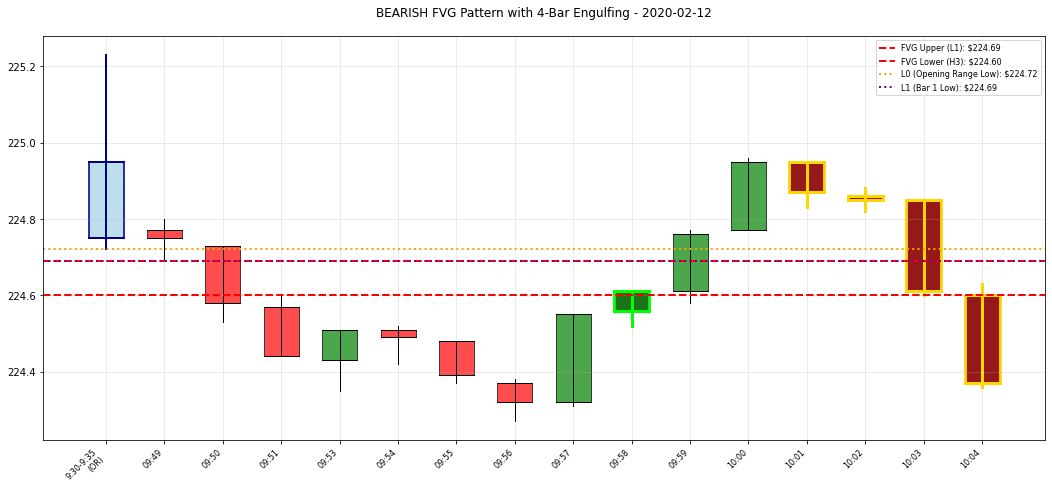

2020-02-20: BEARISH FVG found at 2020-02-20 11:02:00-05:00! Range: [227.55, 227.59]
  L0: 227.62, L1: 227.59
2020-02-27: BEARISH FVG found at 2020-02-27 11:46:00-05:00! Range: [202.48, 202.66]
  L0: 202.65, L1: 202.66
2020-03-06: BEARISH FVG found at 2020-03-06 14:35:00-05:00! Range: [196.58, 196.74]
  L0: 196.82, L1: 196.74
  Retracement at 2020-03-06 14:45:00-05:00
  SHORT SIGNAL (Multi-Bar Bearish Engulfing: 2 bars) at 2020-03-06 14:47:00-05:00
  Entry: 2020-03-06 14:48:00-05:00 @ $196.20
  Stop Loss: $198.16, Target: $193.26


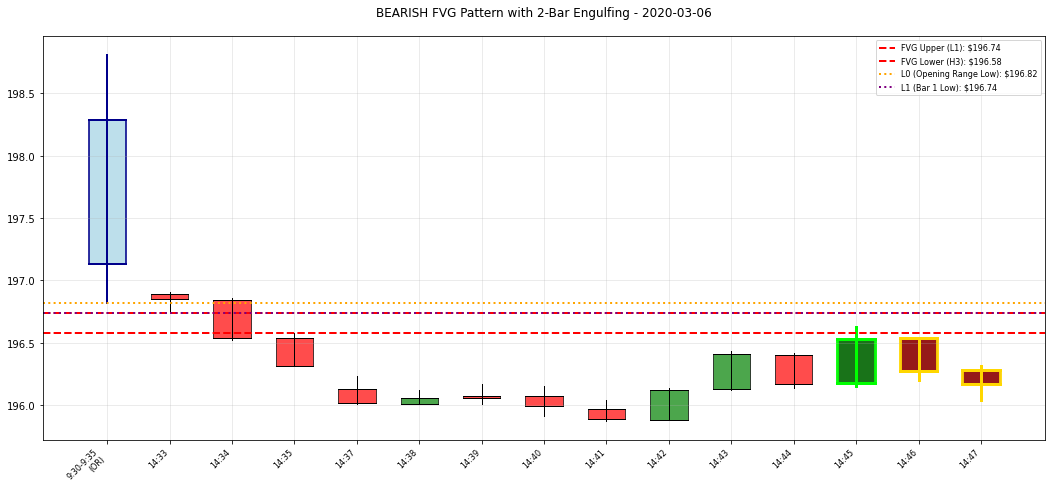

2020-03-12: BEARISH FVG found at 2020-03-12 12:30:00-04:00! Range: [174.44, 174.8]
  L0: 174.34, L1: 174.80
  Retracement at 2020-03-12 12:51:00-04:00
  SHORT SIGNAL (Multi-Bar Bearish Engulfing: 5 bars) at 2020-03-12 15:15:00-04:00
  Entry: 2020-03-12 15:16:00-04:00 @ $173.19
  Stop Loss: $174.92, Target: $170.59


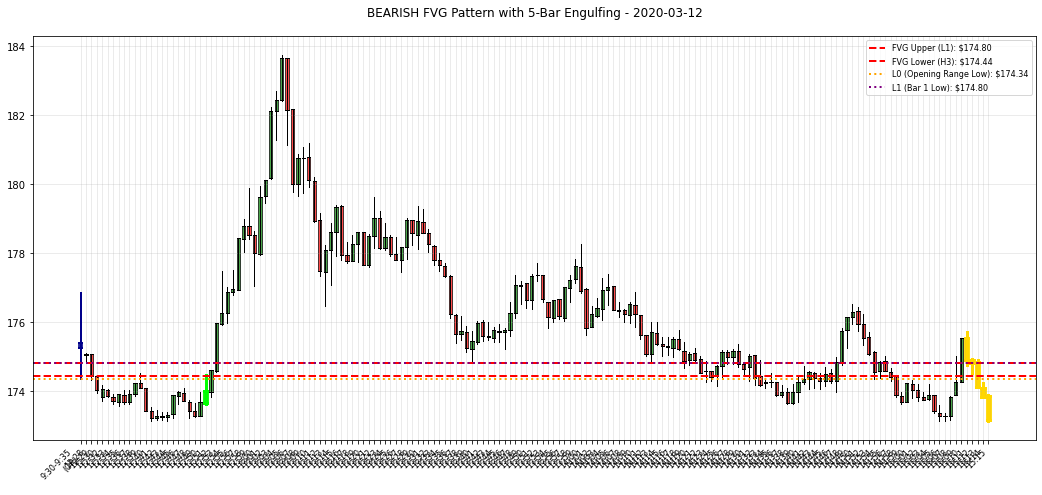

2020-03-18: BEARISH FVG found at 2020-03-18 15:21:00-04:00! Range: [164.12, 164.81]
  L0: 164.49, L1: 164.81
  Retracement at 2020-03-18 15:23:00-04:00
  SHORT SIGNAL (Multi-Bar Bearish Engulfing: 1 bars) at 2020-03-18 15:24:00-04:00
  Entry: 2020-03-18 15:25:00-04:00 @ $163.21
  Stop Loss: $164.84, Target: $160.76


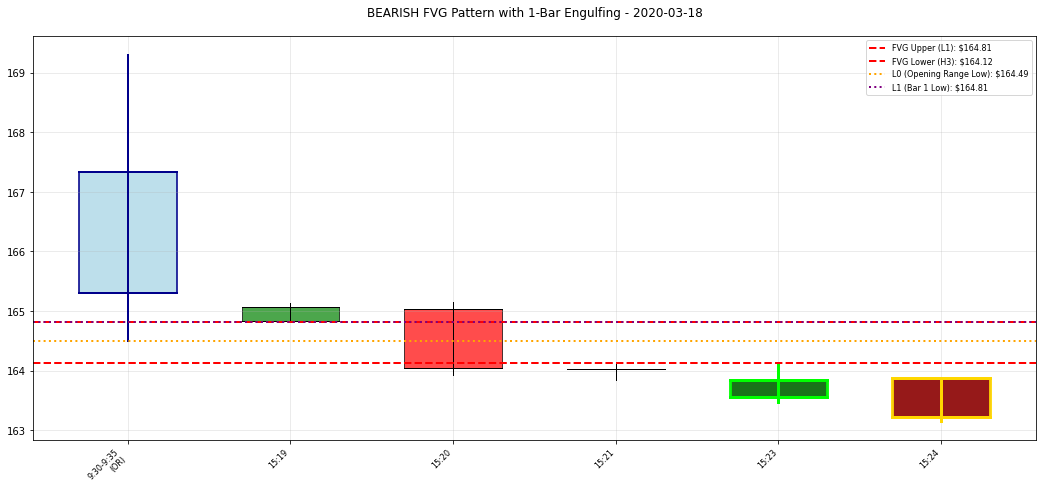

2020-03-20: BEARISH FVG found at 2020-03-20 10:06:00-04:00! Range: [174.1, 174.14]
  L0: 173.73, L1: 174.14
2020-05-01: BEARISH FVG found at 2020-05-01 11:31:00-04:00! Range: [206.71, 206.9]
  L0: 206.82, L1: 206.90
  Retracement at 2020-05-01 11:35:00-04:00
  SHORT SIGNAL (Multi-Bar Bearish Engulfing: 3 bars) at 2020-05-01 11:45:00-04:00
  Entry: 2020-05-01 11:46:00-04:00 @ $206.20
  Stop Loss: $208.26, Target: $203.11


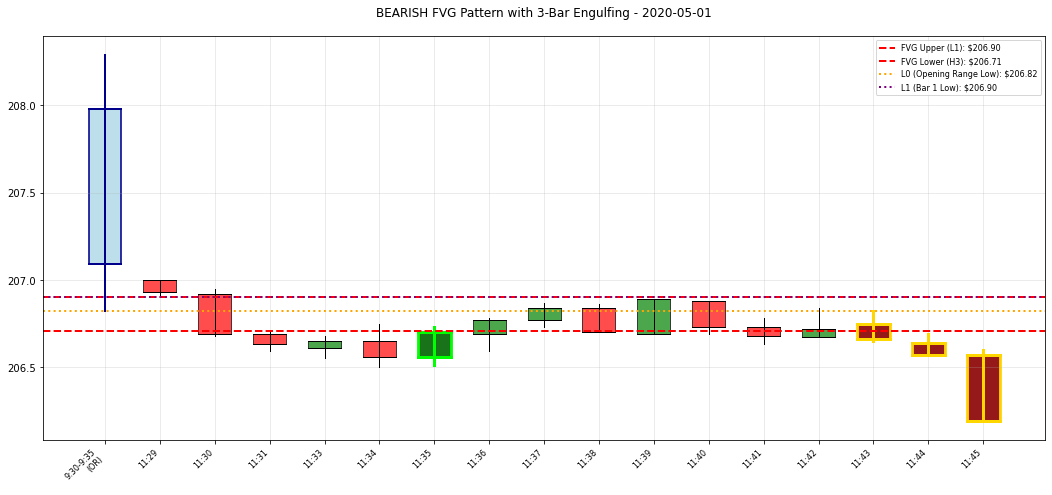


Total SHORT signals detected: 159
Total signals plotted: 5

Trades DataFrame:
           date        fvg_formation_time         fvg_complete_time  \
0    2020-02-12 2020-02-12 09:49:00-05:00 2020-02-12 09:51:00-05:00   
1    2020-03-06 2020-03-06 14:33:00-05:00 2020-03-06 14:35:00-05:00   
2    2020-03-12 2020-03-12 12:28:00-04:00 2020-03-12 12:30:00-04:00   
3    2020-03-18 2020-03-18 15:19:00-04:00 2020-03-18 15:21:00-04:00   
4    2020-05-01 2020-05-01 11:29:00-04:00 2020-05-01 11:31:00-04:00   
..          ...                       ...                       ...   
154  2025-06-05 2025-06-05 09:44:00-04:00 2025-06-05 09:46:00-04:00   
155  2025-06-13 2025-06-13 10:19:00-04:00 2025-06-13 10:21:00-04:00   
156  2025-06-30 2025-06-30 09:42:00-04:00 2025-06-30 09:44:00-04:00   
157  2025-07-07 2025-07-07 10:55:00-04:00 2025-07-07 10:57:00-04:00   
158  2025-07-10 2025-07-10 09:44:00-04:00 2025-07-10 09:46:00-04:00   

             retracement_time               signal_time  \
0   2020-

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert timestamps to NYC time
for ticker, df in data_dict.items():
    if df['timestamp'].dt.tz is None:
        df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
    df['timestamp'] = df['timestamp'].dt.tz_convert('America/New_York')

# Get QQQ data
qqq_data = data_dict['QQQ']

# Filter to market hours (9:30 AM to 4:00 PM NYC time)
qqq_data = qqq_data[(qqq_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                     (qqq_data['timestamp'].dt.time <= pd.Timestamp('16:00').time())]

# Get unique dates
dates = qqq_data['timestamp'].dt.date.unique()

signal_count = 0
plot_count = 0
max_plots = 5

# DataFrame to store trades
trades = []

for date in dates:
    # Filter data for this day
    day_data = qqq_data[qqq_data['timestamp'].dt.date == date].reset_index(drop=True)
    
    # Get first bar (9:30 to 9:35)
    first_bar_data = day_data[(day_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                               (day_data['timestamp'].dt.time <= pd.Timestamp('09:35').time())]
    
    if first_bar_data.empty:
        continue
    
    # Create 5-minute bar
    first_bar = {
        'open': first_bar_data.iloc[0]['open'],
        'high': first_bar_data['high'].max(),
        'low': first_bar_data['low'].min(),
        'close': first_bar_data.iloc[-1]['close'],
        'volume': first_bar_data['volume'].sum(),
        'trade_count': first_bar_data['trade_count'].sum(),
        'vwap': (first_bar_data['vwap'] * first_bar_data['volume']).sum() / first_bar_data['volume'].sum()
    }
    
    H0 = first_bar['high']
    L0 = first_bar['low']
    
    # Start after 9:35
    remaining_data = day_data[day_data['timestamp'].dt.time > pd.Timestamp('09:35').time()].reset_index(drop=True)
    
    # Initialize FVG variables (BEARISH)
    expansion = False
    fvg_signal = False
    fvg_range = None
    fvg_time = None
    fvg_bars = []
    fvg_bar1_time = None  # Time of first FVG bar
    
    H1, L1, O1, C1 = None, None, None, None
    H2, L2, O2, C2 = None, None, None, None
    
    for i, row in remaining_data.iterrows():
        if not fvg_signal:
            if not expansion:
                # Looking for bar 1 or bar 2 (BEARISH)
                if L1 is None:
                    # Set bar 1
                    H1 = row['high']
                    L1 = row['low']
                    O1 = row['open']
                    C1 = row['close']
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # BEARISH CONDITION: O1 must be HIGHER than L0
                    if O1 <= L0:
                        # Reset and continue looking
                        H1, L1, O1, C1 = None, None, None, None
                        continue
                else:
                    # Check if this is bar 2 (expansion + gap) - BEARISH
                    H2 = row['high']
                    L2 = row['low']
                    O2 = row['open']
                    C2 = row['close']
                    
                    # Prevent division by zero
                    if (H1 - L1) == 0:
                        H1, L1, O1, C1 = H2, L2, O2, C2
                        bar1_idx = i
                        bar1_time = row['timestamp']
                        
                        # BEARISH CONDITION: O1 must be HIGHER than L0
                        if O1 <= L0:
                            H1, L1, O1, C1 = None, None, None, None
                        continue
                    
                    # BEARISH EXPANSION: 1.75x larger AND bearish
                    expansion_condition = (H2 - L2) / (H1 - L1) > 1.75 and C2 < O2
                    # BEARISH GAP: Opens below Bar 1 close
                    gap_condition = O2 < C1
                    
                    if expansion_condition and gap_condition:
                        expansion = True
                        bar2_idx = i
                    else:
                        # Failed, set this bar as new bar 1
                        H1, L1, O1, C1 = H2, L2, O2, C2
                        bar1_idx = i
                        bar1_time = row['timestamp']
                        
                        # BEARISH CONDITION: O1 must be HIGHER than L0
                        if O1 <= L0:
                            H1, L1, O1, C1 = None, None, None, None
            else:
                # Looking for bar 3 (consolidation + gap kept) - BEARISH
                H3 = row['high']
                L3 = row['low']
                C3 = row['close']
                O3 = row['open']
                
                # Prevent division by zero
                if (H2 - L2) == 0:
                    expansion = False
                    H1, L1, O1, C1 = H3, L3, row['open'], row['close']
                    H2, L2, O2, C2 = None, None, None, None
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # BEARISH CONDITION: O1 must be HIGHER than L0
                    if O1 <= L0:
                        H1, L1, O1, C1 = None, None, None, None
                    continue
                
                # CONSOLIDATION (same ratio)
                consolidation_condition = (H3 - L3) / (H2 - L2) < 1.0
                # BEARISH GAP KEPT: Bar 3 high stays below Bar 1 low
                gap_kept_condition = H3 < L1
                # BEARISH CONDITION: C3 must be BELOW L0
                c3_below_l0_condition = C3 < L0
                
                if consolidation_condition and gap_kept_condition and c3_below_l0_condition:
                    fvg_signal = True
                    # BEARISH FVG RANGE: [H3, L1]
                    fvg_range = [H3, L1]
                    fvg_time = row['timestamp']  # Time when FVG completes (bar 3)
                    fvg_bar1_time = bar1_time  # Time of first bar of FVG
                    bar3_idx = i
                    fvg_bars = [
                        {'o': O1, 'h': H1, 'l': L1, 'c': C1, 'time': remaining_data.iloc[bar1_idx]['timestamp']},
                        {'o': O2, 'h': H2, 'l': L2, 'c': C2, 'time': remaining_data.iloc[bar2_idx]['timestamp']},
                        {'o': row['open'], 'h': H3, 'l': L3, 'c': C3, 'time': row['timestamp']}
                    ]
                    if plot_count < max_plots:
                        print(f"{date}: BEARISH FVG found at {fvg_time}! Range: {fvg_range}")
                        print(f"  L0: {L0:.2f}, L1: {L1:.2f}")
                    
                else:
                    # Failed, reset and set this bar as new bar 1
                    expansion = False
                    H1, L1, O1, C1 = H3, L3, row['open'], row['close']
                    H2, L2, O2, C2 = None, None, None, None
                    bar1_idx = i
                    bar1_time = row['timestamp']
                    
                    # BEARISH CONDITION: O1 must be HIGHER than L0
                    if O1 <= L0:
                        H1, L1, O1, C1 = None, None, None, None
        else:
            # FVG found, now looking for retracement (BEARISH)
            retracement = False
            retracement_bar = None
            retracement_idx = None
            bars_after_fvg = []
            
            for j in range(i+1, len(remaining_data)):
                bar = remaining_data.iloc[j]
                bars_after_fvg.append(bar)
                
                if not retracement:
                    # Looking for BULLISH bar entering FVG zone
                    is_bullish = bar['close'] > bar['open']
                    # BEARISH FVG: Bar's high must be INSIDE the gap
                    enters_fvg = bar['high'] > fvg_range[0] and bar['high'] < fvg_range[1]
                    
                    # PATTERN INVALIDATION: If price breaks ABOVE L1, pattern is broken
                    breaks_above_fvg = bar['close'] > fvg_range[1]
                    
                    if breaks_above_fvg:
                        # Pattern failed - price recovered too much, cancel signal
                        break
                    
                    if is_bullish and enters_fvg:
                        retracement = True
                        retracement_idx = len(bars_after_fvg) - 1  # Index within bars_after_fvg
                        retracement_bar = {
                            'o': bar['open'],
                            'h': bar['high'],
                            'l': bar['low'],
                            'c': bar['close'],
                            'time': bar['timestamp']
                        }
                        # Initialize bearish bars accumulator
                        bearish_bars = []
                        if plot_count < max_plots:
                            print(f"  Retracement at {retracement_bar['time']}")
                else:
                    # Looking for multi-bar BEARISH engulfing
                    is_bearish = bar['close'] < bar['open']
                    
                    if is_bearish:
                        # Add to our bearish bar accumulator
                        bearish_bars.append({
                            'open': bar['open'],
                            'close': bar['close'],
                            'high': bar['high'],
                            'low': bar['low'],
                            'time': bar['timestamp']
                        })
                        
                        # Check multi-bar BEARISH engulfing condition
                        max_open = max(b['open'] for b in bearish_bars)
                        min_close = min(b['close'] for b in bearish_bars)
                        
                        # BEARISH Engulfing: max_open >= retracement_close AND min_close <= retracement_open
                        engulfs = (max_open >= retracement_bar['c']) and (min_close <= retracement_bar['o'])
                    else:
                        # Non-bearish bar: reset accumulator and keep looking
                        bearish_bars = []
                        engulfs = False
                    
                    if engulfs:
                        signal_time = bar['timestamp']
                        signal_idx = len(bars_after_fvg) - 1  # Index within bars_after_fvg
                        num_engulfing_bars = len(bearish_bars)
                        
                        # Entry is next bar
                        if j + 1 < len(remaining_data):
                            entry_bar = remaining_data.iloc[j + 1]
                            entry_time = entry_bar['timestamp']
                            entry_price = entry_bar['open']
                            
                            # BEARISH: Stop loss 1.0% ABOVE entry (mirror of bullish 1% below)
                            stop_loss = entry_price * 1.01
                            risk = stop_loss - entry_price
                            # BEARISH: Profit target 1.5R BELOW entry (mirror of bullish 1.5R above)
                            profit_target = entry_price - (1.5 * risk)
                            
                            # Store trade with retracement and signal times
                            trades.append({
                                'date': date,
                                'fvg_formation_time': fvg_bar1_time,
                                'fvg_complete_time': fvg_time,
                                'retracement_time': retracement_bar['time'],
                                'signal_time': signal_time,
                                'entry_time': entry_time,
                                'entry_price': entry_price,
                                'stop_loss': stop_loss,
                                'profit_target': profit_target,
                                'risk': risk,
                                'fvg_range': fvg_range,
                                'H0': H0,
                                'L0': L0,
                                'L1': L1,
                                'num_engulfing_bars': num_engulfing_bars
                            })
                            
                            if plot_count < max_plots:
                                print(f"  SHORT SIGNAL (Multi-Bar Bearish Engulfing: {num_engulfing_bars} bars) at {signal_time}")
                                print(f"  Entry: {entry_time} @ ${entry_price:.2f}")
                                print(f"  Stop Loss: ${stop_loss:.2f}, Target: ${profit_target:.2f}")
                            
                            signal_count += 1
                            
                            # Only plot first max_plots signals
                            if plot_count < max_plots:
                                # Create opening range bar for reference
                                opening_bar = {
                                    'o': first_bar['open'],
                                    'h': first_bar['high'],
                                    'l': first_bar['low'],
                                    'c': first_bar['close'],
                                    'time': pd.Timestamp('09:30').time()  # Label it as 9:30
                                }
                                
                                # Plot Opening bar + FVG bars + all bars until signal
                                all_bars = [opening_bar] + fvg_bars + [{'o': b['open'], 'h': b['high'], 'l': b['low'], 
                                                        'c': b['close'], 'time': b['timestamp']} 
                                                       for b in bars_after_fvg[:j-i+1]]
                                
                                # Adjust indices to match all_bars array (add 1 for opening bar offset)
                                retracement_plot_idx = 1 + 3 + retracement_idx  # 1 opening bar + 3 FVG bars + position in bars_after_fvg
                                signal_plot_idx = 1 + 3 + signal_idx  # 1 opening bar + 3 FVG bars + position in bars_after_fvg
                                
                                # Calculate engulfing bars indices (the last num_engulfing_bars before signal)
                                engulfing_start_idx = signal_plot_idx - num_engulfing_bars + 1
                                engulfing_indices = list(range(engulfing_start_idx, signal_plot_idx + 1))
                                
                                fig, ax = plt.subplots(figsize=(16, 7))
                                for k, bar_data in enumerate(all_bars):
                                    # Determine special highlighting
                                    if k == 0:
                                        # Opening range bar - highlight with special color
                                        color = 'lightblue'
                                        edgecolor = 'darkblue'
                                        linewidth = 2
                                        alpha = 0.8
                                    elif k == retracement_plot_idx:
                                        # Retracement bar - BULLISH for bearish FVG
                                        color = 'darkgreen'
                                        edgecolor = 'lime'
                                        linewidth = 3
                                        alpha = 0.9
                                    elif k in engulfing_indices:
                                        # Multi-bar BEARISH engulfing bars
                                        color = 'darkred'
                                        edgecolor = 'gold'
                                        linewidth = 3
                                        alpha = 0.9
                                    else:
                                        # Normal bars
                                        color = 'green' if bar_data['c'] >= bar_data['o'] else 'red'
                                        edgecolor = 'black'
                                        linewidth = 1
                                        alpha = 0.7
                                    
                                    # Draw candlestick
                                    ax.plot([k, k], [bar_data['l'], bar_data['h']], color=edgecolor, linewidth=linewidth)
                                    ax.plot([k-0.3, k+0.3], [bar_data['o'], bar_data['o']], color=edgecolor, linewidth=linewidth)
                                    ax.plot([k-0.3, k+0.3], [bar_data['c'], bar_data['c']], color=edgecolor, linewidth=linewidth)
                                    ax.add_patch(plt.Rectangle((k-0.3, min(bar_data['o'], bar_data['c'])), 0.6, 
                                                               abs(bar_data['c']-bar_data['o']), 
                                                               facecolor=color, edgecolor=edgecolor, 
                                                               linewidth=linewidth, alpha=alpha))
                                
                                # BEARISH FVG zone
                                ax.axhline(y=fvg_range[1], color='red', linestyle='--', linewidth=2, 
                                          label=f'FVG Upper (L1): ${fvg_range[1]:.2f}')
                                ax.axhline(y=fvg_range[0], color='red', linestyle='--', linewidth=2, 
                                          label=f'FVG Lower (H3): ${fvg_range[0]:.2f}')
                                
                                # L0 and L1 lines
                                ax.axhline(y=L0, color='orange', linestyle=':', linewidth=2, 
                                          label=f'L0 (Opening Range Low): ${L0:.2f}')
                                ax.axhline(y=L1, color='purple', linestyle=':', linewidth=2, 
                                          label=f'L1 (Bar 1 Low): ${L1:.2f}')
                                
                                ax.set_xticks(range(len(all_bars)))
                                # Format time labels, special handling for opening bar
                                time_labels = []
                                for k, b in enumerate(all_bars):
                                    if k == 0:
                                        time_labels.append('9:30-9:35\n(OR)')
                                    else:
                                        time_labels.append(b['time'].strftime('%H:%M'))
                                ax.set_xticklabels(time_labels, rotation=45, ha='right', fontsize=8)
                                ax.set_title(f'BEARISH FVG Pattern with {num_engulfing_bars}-Bar Engulfing - {date}', fontsize=12, pad=20)
                                ax.legend(loc='upper right', fontsize=8)
                                ax.grid(True, alpha=0.3)
                                
                                # Add some padding to prevent cutoff
                                plt.subplots_adjust(bottom=0.12, top=0.92, left=0.08, right=0.95)
                                plt.show()
                                
                                plot_count += 1
                        break
            
            break

trades_df = pd.DataFrame(trades)
print(f"\nTotal SHORT signals detected: {signal_count}")
print(f"Total signals plotted: {plot_count}")
print("\nTrades DataFrame:")
print(trades_df)


Trade 1 - 2020-02-12
FVG Formation: 2020-02-12 09:49:00-05:00
Signal: 2020-02-12 10:04:00-05:00
Entry: 2020-02-12 10:05:00-05:00 @ $224.38
Exit: 2020-02-12 16:00:00-05:00 @ $225.71 (End of Day)
Return: -0.59%


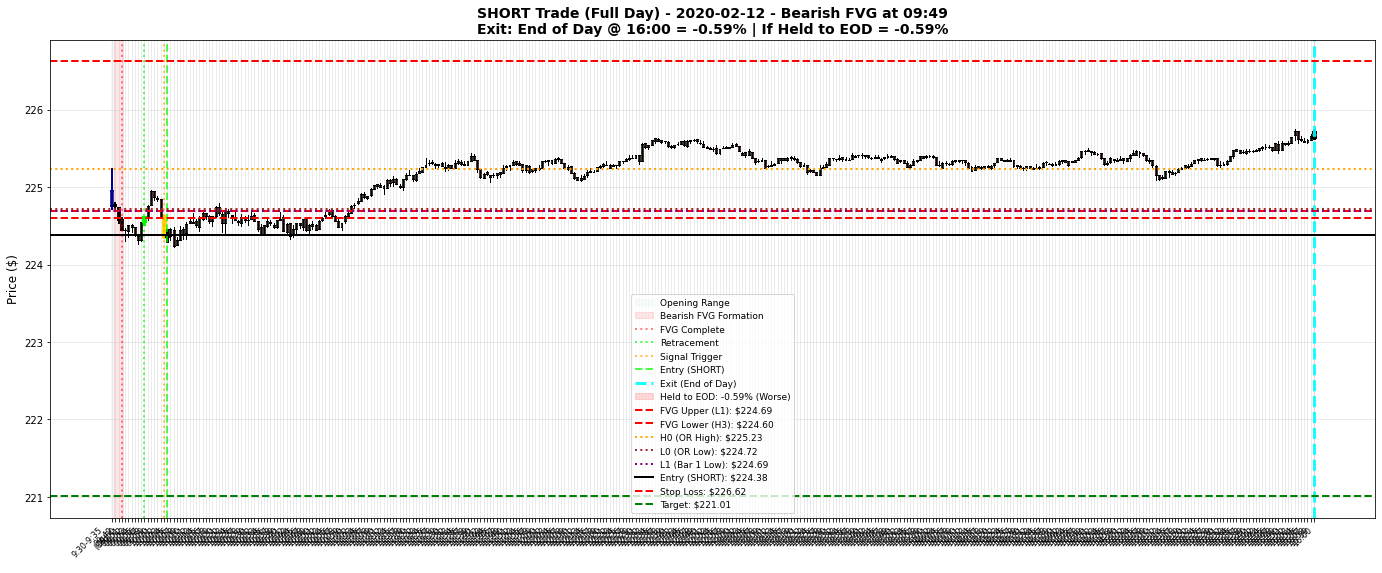


Trade 2 - 2020-03-06
FVG Formation: 2020-03-06 14:33:00-05:00
Signal: 2020-03-06 14:47:00-05:00
Entry: 2020-03-06 14:48:00-05:00 @ $196.20
Exit: 2020-03-06 15:32:00-05:00 @ $198.16 (Stop Loss)
Return: -1.00%


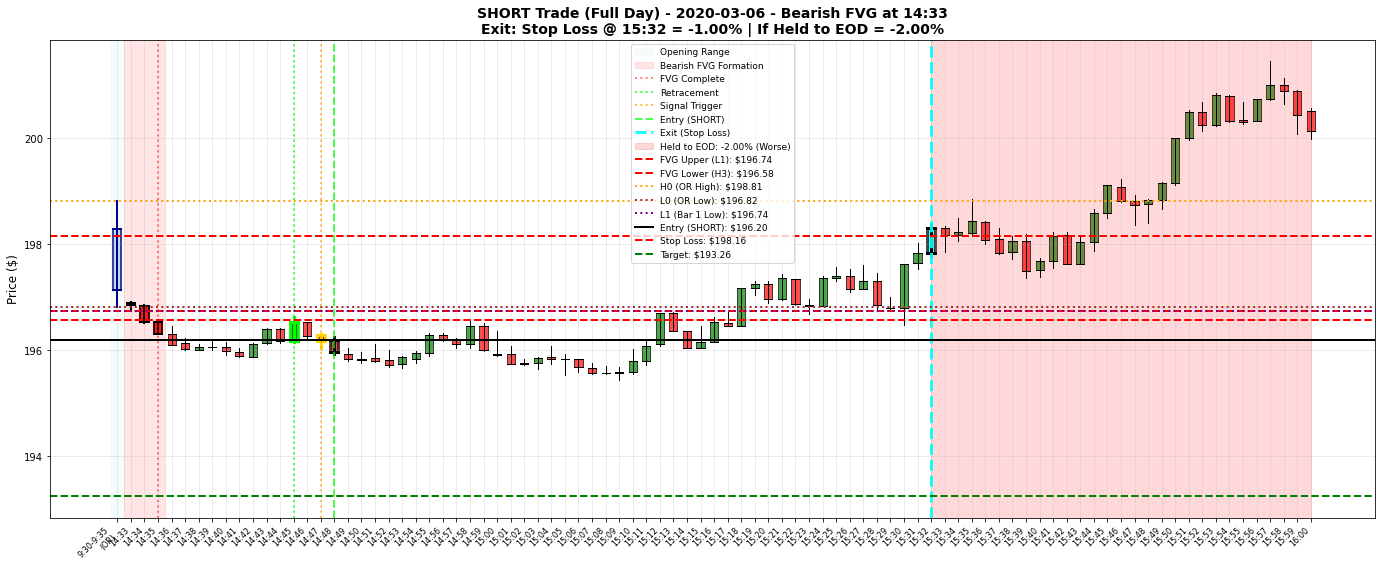


Trade 3 - 2020-03-12
FVG Formation: 2020-03-12 12:28:00-04:00
Signal: 2020-03-12 15:15:00-04:00
Entry: 2020-03-12 15:16:00-04:00 @ $173.19
Exit: 2020-03-12 15:50:00-04:00 @ $174.92 (Stop Loss)
Return: -1.00%


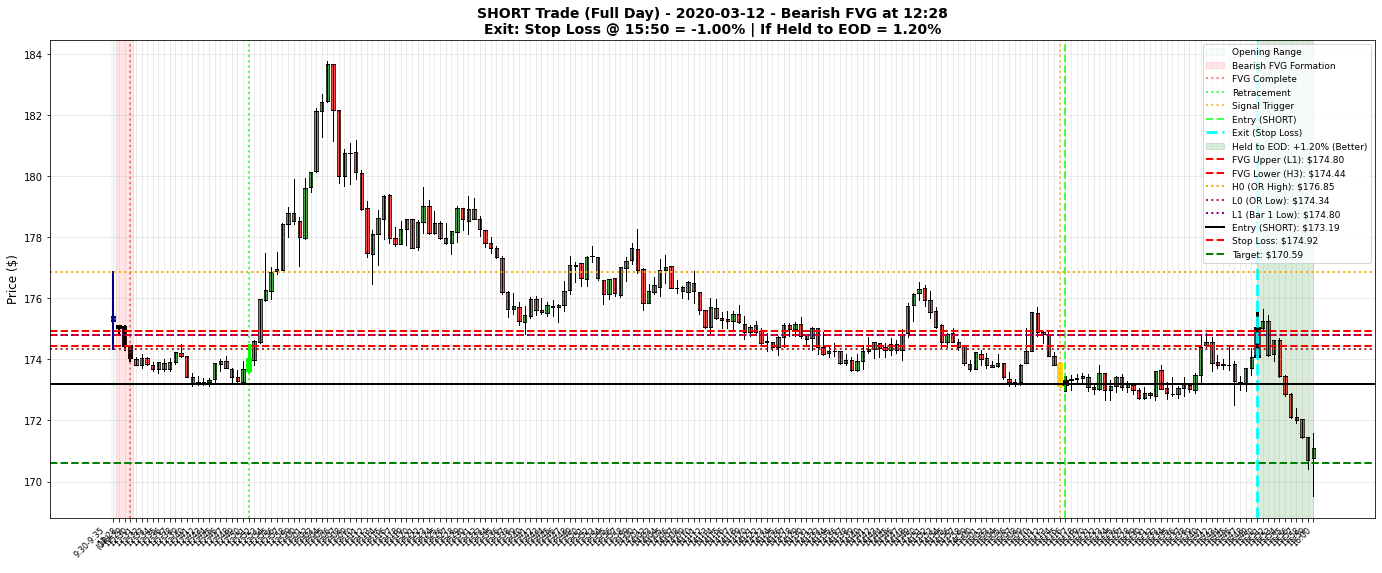


Trade 4 - 2020-03-18
FVG Formation: 2020-03-18 15:19:00-04:00
Signal: 2020-03-18 15:24:00-04:00
Entry: 2020-03-18 15:25:00-04:00 @ $163.21
Exit: 2020-03-18 15:49:00-04:00 @ $164.84 (Stop Loss)
Return: -1.00%


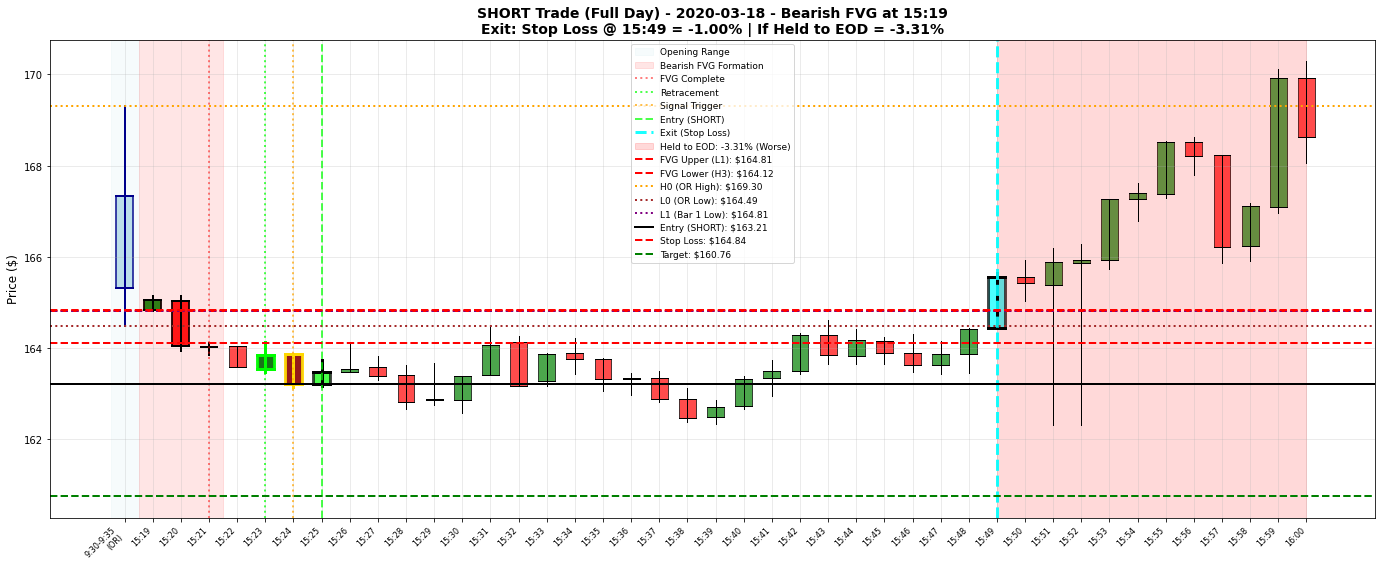


Trade 5 - 2020-05-01
FVG Formation: 2020-05-01 11:29:00-04:00
Signal: 2020-05-01 11:45:00-04:00
Entry: 2020-05-01 11:46:00-04:00 @ $206.20
Exit: 2020-05-01 16:00:00-04:00 @ $205.36 (End of Day)
Return: 0.41%


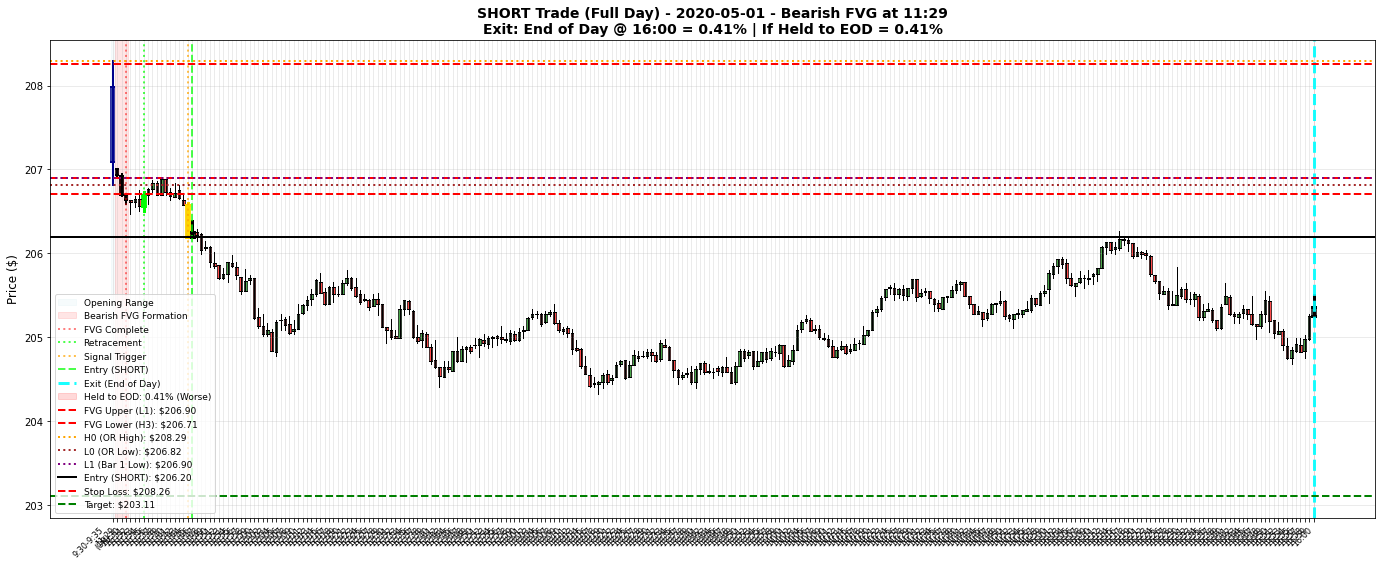


SHORT TRADE RESULTS SUMMARY
           date        fvg_formation_time               signal_time  \
0    2020-02-12 2020-02-12 09:49:00-05:00 2020-02-12 10:04:00-05:00   
1    2020-03-06 2020-03-06 14:33:00-05:00 2020-03-06 14:47:00-05:00   
2    2020-03-12 2020-03-12 12:28:00-04:00 2020-03-12 15:15:00-04:00   
3    2020-03-18 2020-03-18 15:19:00-04:00 2020-03-18 15:24:00-04:00   
4    2020-05-01 2020-05-01 11:29:00-04:00 2020-05-01 11:45:00-04:00   
..          ...                       ...                       ...   
154  2025-06-05 2025-06-05 09:44:00-04:00 2025-06-05 09:57:00-04:00   
155  2025-06-13 2025-06-13 10:19:00-04:00 2025-06-13 10:27:00-04:00   
156  2025-06-30 2025-06-30 09:42:00-04:00 2025-06-30 14:32:00-04:00   
157  2025-07-07 2025-07-07 10:55:00-04:00 2025-07-07 12:20:00-04:00   
158  2025-07-10 2025-07-10 09:44:00-04:00 2025-07-10 13:45:00-04:00   

                   entry_time  entry_price                 exit_time  \
0   2020-02-12 10:05:00-05:00       224.38 202

In [66]:
# Execute trades and analyze results - BEARISH/SHORT VERSION
results = []
plot_count = 0
max_plots = 5

for idx, trade in trades_df.iterrows():
    date = trade['date']
    fvg_formation_time = trade['fvg_formation_time']
    fvg_complete_time = trade['fvg_complete_time']
    retracement_time = trade['retracement_time']
    signal_time = trade['signal_time']
    entry_time = trade['entry_time']
    entry_price = trade['entry_price']
    stop_loss = trade['stop_loss']
    profit_target = trade['profit_target']
    fvg_range = trade['fvg_range']
    H0 = trade['H0'] if 'H0' in trade else None
    L0 = trade['L0']
    L1 = trade['L1'] if 'L1' in trade else None
    
    # Get data from entry time onwards
    day_data = qqq_data[qqq_data['timestamp'].dt.date == date].reset_index(drop=True)
    entry_idx = day_data[day_data['timestamp'] == entry_time].index[0]
    trade_data = day_data.iloc[entry_idx:].reset_index(drop=True)
    
    # Track trade
    exit_time = None
    exit_price = None
    exit_reason = None
    
    trade_bars = []
    
    for i, bar in trade_data.iterrows():
        trade_bars.append(bar)
        
        # SHORT: Check stop loss (price goes UP to hit stop)
        if bar['high'] >= stop_loss:
            exit_time = bar['timestamp']
            exit_price = stop_loss
            exit_reason = 'Stop Loss'
            break
        
        # SHORT: Check profit target (price goes DOWN to hit target)
        if bar['low'] <= profit_target:
            exit_time = bar['timestamp']
            exit_price = profit_target
            exit_reason = 'Profit Target'
            break
    
    # If no exit, close at end of day
    if exit_time is None:
        exit_time = trade_data.iloc[-1]['timestamp']
        exit_price = trade_data.iloc[-1]['close']
        exit_reason = 'End of Day'
    
    # SHORT: Calculate returns (profit when price goes down)
    pct_return = ((entry_price - exit_price) / entry_price) * 100
    
    # Store result
    results.append({
        'date': date,
        'fvg_formation_time': fvg_formation_time,
        'signal_time': signal_time,
        'entry_time': entry_time,
        'entry_price': entry_price,
        'exit_time': exit_time,
        'exit_price': exit_price,
        'exit_reason': exit_reason,
        'pct_return': pct_return,
        'stop_loss': stop_loss,
        'profit_target': profit_target
    })
    
    if plot_count < max_plots:
        print(f"\nTrade {idx + 1} - {date}")
        print(f"FVG Formation: {fvg_formation_time}")
        print(f"Signal: {signal_time}")
        print(f"Entry: {entry_time} @ ${entry_price:.2f}")
        print(f"Exit: {exit_time} @ ${exit_price:.2f} ({exit_reason})")
        print(f"Return: {pct_return:.2f}%")
    
    # Only plot first max_plots trades
    if plot_count < max_plots:
        # Get opening range bar for this date
        first_bar_data = day_data[(day_data['timestamp'].dt.time >= pd.Timestamp('09:30').time()) & 
                                   (day_data['timestamp'].dt.time <= pd.Timestamp('09:35').time())]
        
        if not first_bar_data.empty:
            opening_bar = pd.Series({
                'timestamp': pd.Timestamp(f"{date} 09:30:00").tz_localize('America/New_York'),
                'open': first_bar_data.iloc[0]['open'],
                'high': first_bar_data['high'].max(),
                'low': first_bar_data['low'].min(),
                'close': first_bar_data.iloc[-1]['close']
            })
        
        # Get all bars from FVG formation to END OF DAY (not just exit)
        full_trade_data = day_data[day_data['timestamp'] >= fvg_formation_time].reset_index(drop=True)
        
        # Insert opening bar at the beginning
        if not first_bar_data.empty:
            full_trade_data = pd.concat([pd.DataFrame([opening_bar]), full_trade_data], ignore_index=True)
        
        # Find special bar indices (add 1 offset for opening bar)
        fvg_complete_idx = None
        retracement_idx = None
        signal_idx = None
        entry_bar_idx = None
        exit_bar_idx = None
        
        for i, bar in full_trade_data.iterrows():
            if i == 0:  # Skip opening bar
                continue
            if bar['timestamp'] == fvg_complete_time:
                fvg_complete_idx = i
            if bar['timestamp'] == retracement_time:
                retracement_idx = i
            if bar['timestamp'] == signal_time:
                signal_idx = i
            if bar['timestamp'] == entry_time:
                entry_bar_idx = i
            if bar['timestamp'] == exit_time:
                exit_bar_idx = i
        
        # Plot complete trade view
        fig, ax = plt.subplots(figsize=(20, 8))
        
        for k, bar in full_trade_data.iterrows():
            # Default styling
            color = 'green' if bar['close'] >= bar['open'] else 'red'
            alpha = 0.7
            linewidth = 1
            edgecolor = 'black'
            
            # Highlight opening range bar
            if k == 0:
                color = 'lightblue'
                edgecolor = 'darkblue'
                linewidth = 2
                alpha = 0.8
            
            # Highlight FVG formation bars (bars 1-3, now indices 1-3 due to opening bar)
            elif k >= 1 and k <= 3:
                alpha = 0.9
                linewidth = 2
            
            # Highlight retracement bar (BULLISH for bearish FVG)
            elif k == retracement_idx:
                color = 'darkgreen'
                edgecolor = 'lime'
                linewidth = 3
                alpha = 0.9
            
            # Highlight signal bar (BEARISH engulfing)
            elif k == signal_idx:
                color = 'darkred'
                edgecolor = 'gold'
                linewidth = 3
                alpha = 0.9
            
            # Highlight entry bar
            elif k == entry_bar_idx:
                linewidth = 3
                color = 'lime' if bar['close'] >= bar['open'] else 'red'
            
            # Highlight exit bar
            elif k == exit_bar_idx:
                linewidth = 3
                color = 'cyan' if bar['close'] >= bar['open'] else 'purple'
            
            ax.plot([k, k], [bar['low'], bar['high']], color=edgecolor, linewidth=linewidth)
            ax.plot([k-0.3, k+0.3], [bar['open'], bar['open']], color=edgecolor, linewidth=linewidth)
            ax.plot([k-0.3, k+0.3], [bar['close'], bar['close']], color=edgecolor, linewidth=linewidth)
            ax.add_patch(plt.Rectangle((k-0.3, min(bar['open'], bar['close'])), 0.6, 
                                       abs(bar['close']-bar['open']), facecolor=color, 
                                       edgecolor=edgecolor, linewidth=linewidth, alpha=alpha))
        
        # Mark opening range
        ax.axvspan(-0.5, 0.5, alpha=0.1, color='lightblue', label='Opening Range')
        
        # Mark BEARISH FVG formation zone (adjusted for opening bar offset)
        ax.axvspan(0.5, 3.5, alpha=0.1, color='red', label='Bearish FVG Formation')
        
        # Mark FVG completion
        if fvg_complete_idx is not None:
            ax.axvline(x=fvg_complete_idx, color='red', linestyle=':', linewidth=2, alpha=0.5, label='FVG Complete')
        
        # Mark retracement
        if retracement_idx is not None:
            ax.axvline(x=retracement_idx, color='lime', linestyle=':', linewidth=2, alpha=0.7, label='Retracement')
        
        # Mark signal and entry with vertical lines
        if signal_idx is not None:
            ax.axvline(x=signal_idx, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Signal Trigger')
        if entry_bar_idx is not None:
            ax.axvline(x=entry_bar_idx, color='lime', linestyle='--', linewidth=2, alpha=0.7, label='Entry (SHORT)')
        if exit_bar_idx is not None:
            ax.axvline(x=exit_bar_idx, color='cyan', linestyle='--', linewidth=3, alpha=0.9, label=f'Exit ({exit_reason})')
            
            # Shade the region AFTER exit to show "what if we stayed in?"
            eod_idx = len(full_trade_data) - 1
            eod_price = full_trade_data.iloc[-1]['close']
            
            # Calculate what would have happened if we held to EOD
            pct_if_held = ((entry_price - eod_price) / entry_price) * 100
            
            # Color based on whether holding would have been better
            if pct_if_held > pct_return:
                shade_color = 'green'  # Exited too early
                shade_label = f'Held to EOD: +{pct_if_held:.2f}% (Better)'
            else:
                shade_color = 'red'  # Good exit
                shade_label = f'Held to EOD: {pct_if_held:.2f}% (Worse)'
            
            ax.axvspan(exit_bar_idx, eod_idx, alpha=0.15, color=shade_color, label=shade_label)
        
        # Add horizontal lines - BEARISH FVG
        ax.axhline(y=fvg_range[1], color='red', linestyle='--', linewidth=2, label=f'FVG Upper (L1): ${fvg_range[1]:.2f}')
        ax.axhline(y=fvg_range[0], color='red', linestyle='--', linewidth=2, label=f'FVG Lower (H3): ${fvg_range[0]:.2f}')
        
        if H0 is not None:
            ax.axhline(y=H0, color='orange', linestyle=':', linewidth=2, label=f'H0 (OR High): ${H0:.2f}')
        ax.axhline(y=L0, color='brown', linestyle=':', linewidth=2, label=f'L0 (OR Low): ${L0:.2f}')
        if L1 is not None:
            ax.axhline(y=L1, color='purple', linestyle=':', linewidth=2, label=f'L1 (Bar 1 Low): ${L1:.2f}')
        
        ax.axhline(y=entry_price, color='black', linestyle='-', linewidth=2, label=f'Entry (SHORT): ${entry_price:.2f}')
        ax.axhline(y=stop_loss, color='red', linestyle='--', linewidth=2, label=f'Stop Loss: ${stop_loss:.2f}')
        ax.axhline(y=profit_target, color='green', linestyle='--', linewidth=2, label=f'Target: ${profit_target:.2f}')
        
        ax.set_xticks(range(len(full_trade_data)))
        # Format time labels with special handling for opening bar
        time_labels = []
        for k, bar in full_trade_data.iterrows():
            if k == 0:
                time_labels.append('9:30-9:35\n(OR)')
            else:
                time_labels.append(bar['timestamp'].strftime('%H:%M'))
        ax.set_xticklabels(time_labels, rotation=45, ha='right', fontsize=8)
        
        eod_close = full_trade_data.iloc[-1]['close']
        pct_if_held_to_eod = ((entry_price - eod_close) / entry_price) * 100
        
        ax.set_title(f'SHORT Trade (Full Day) - {date} - Bearish FVG at {fvg_formation_time.strftime("%H:%M")}\n' + 
                     f'Exit: {exit_reason} @ {exit_time.strftime("%H:%M")} = {pct_return:.2f}% | ' +
                     f'If Held to EOD = {pct_if_held_to_eod:.2f}%', 
                     fontsize=14, fontweight='bold')
        ax.set_ylabel('Price ($)', fontsize=12)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.subplots_adjust(bottom=0.12, top=0.95, left=0.06, right=0.98)
        plt.show()
        
        plot_count += 1

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SHORT TRADE RESULTS SUMMARY")
print("="*80)
print(results_df)
print("\n" + "="*80)
print(f"Total Trades: {len(results_df)}")
print(f"Winners: {len(results_df[results_df['pct_return'] > 0])}")
print(f"Losers: {len(results_df[results_df['pct_return'] < 0])}")
if len(results_df) > 0:
    print(f"Win Rate: {(len(results_df[results_df['pct_return'] > 0]) / len(results_df) * 100):.2f}%")
    print(f"Average Return: {results_df['pct_return'].mean():.2f}%")
    print(f"Total Return: {results_df['pct_return'].sum():.2f}%")
print("="*80)

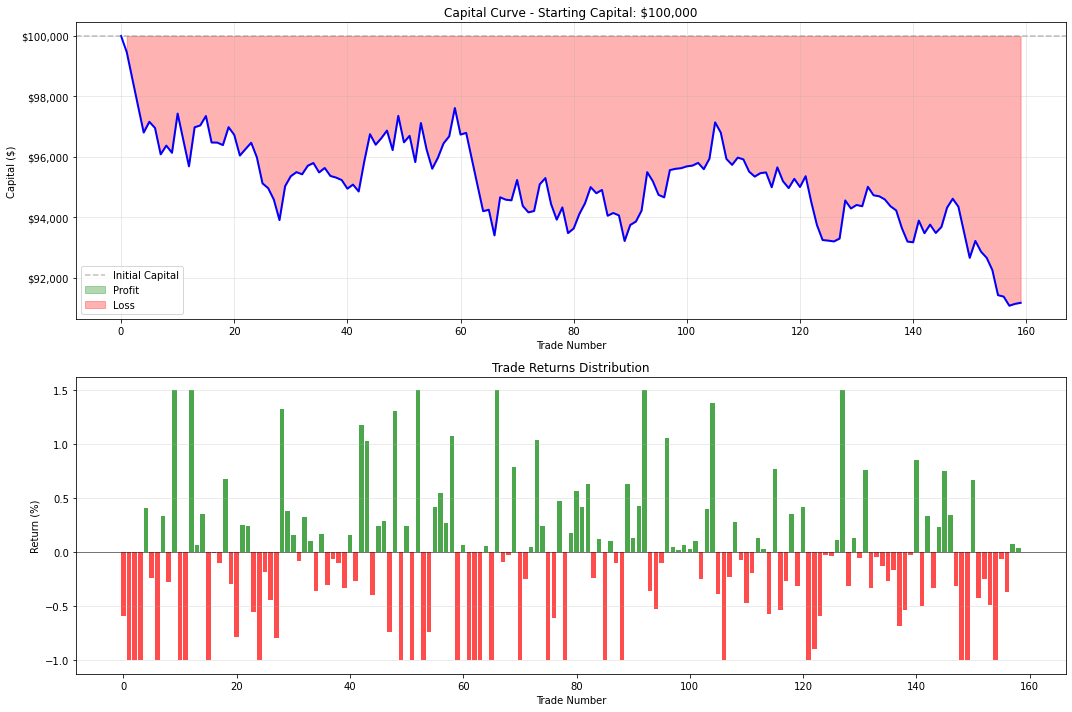


ENHANCED BACKTEST RESULTS
Initial Capital:        $100,000.00
Final Capital:          $91,173.59
Total P&L:              $-8,826.41
Total Return:           -8.83%
Allocation per Trade:   90%
--------------------------------------------------------------------------------
Total Trades:           159
Winning Trades:         71 (44.7%)
Losing Trades:          88 (55.3%)
Win Rate:               44.65%
--------------------------------------------------------------------------------
Average Return:         -0.06%
Average Win:            0.51%
Average Loss:           -0.52%
Profit Factor:          0.78
Max Drawdown:           8.92%
Best Trade:             1.50%
Worst Trade:            -1.00%


In [67]:
# Backtest with capital allocation
initial_capital = 100000
allocation = 0.90  # 90% of capital per trade
capital = initial_capital
capital_history = [initial_capital]
trade_returns = []

for idx, row in results_df.iterrows():
    trade_capital = capital * allocation
    pct_return = row['pct_return'] / 100
    pnl = trade_capital * pct_return
    capital += pnl
    capital_history.append(capital)
    trade_returns.append(pct_return)

# Plot capital curve
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Capital curve
ax1.plot(range(len(capital_history)), capital_history, linewidth=2, color='blue')
ax1.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.fill_between(range(len(capital_history)), initial_capital, capital_history, 
                  where=[c >= initial_capital for c in capital_history], 
                  alpha=0.3, color='green', label='Profit')
ax1.fill_between(range(len(capital_history)), initial_capital, capital_history, 
                  where=[c < initial_capital for c in capital_history], 
                  alpha=0.3, color='red', label='Loss')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Capital ($)')
ax1.set_title(f'Capital Curve - Starting Capital: ${initial_capital:,.0f}')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Trade returns distribution
ax2.bar(range(len(results_df)), results_df['pct_return'], 
        color=['green' if x > 0 else 'red' for x in results_df['pct_return']], alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Trade Number')
ax2.set_ylabel('Return (%)')
ax2.set_title('Trade Returns Distribution')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Enhanced statistics
final_capital = capital_history[-1]
total_pnl = final_capital - initial_capital
total_return_pct = ((final_capital - initial_capital) / initial_capital) * 100

winning_trades = results_df[results_df['pct_return'] > 0]
losing_trades = results_df[results_df['pct_return'] < 0]

avg_win = winning_trades['pct_return'].mean() if len(winning_trades) > 0 else 0
avg_loss = losing_trades['pct_return'].mean() if len(losing_trades) > 0 else 0

# Calculate max drawdown
peak = initial_capital
max_dd = 0
for cap in capital_history:
    if cap > peak:
        peak = cap
    dd = ((peak - cap) / peak) * 100
    if dd > max_dd:
        max_dd = dd

print("\n" + "="*80)
print("ENHANCED BACKTEST RESULTS")
print("="*80)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Capital:          ${final_capital:,.2f}")
print(f"Total P&L:              ${total_pnl:,.2f}")
print(f"Total Return:           {total_return_pct:.2f}%")
print(f"Allocation per Trade:   {allocation*100:.0f}%")
print("-"*80)
print(f"Total Trades:           {len(results_df)}")
print(f"Winning Trades:         {len(winning_trades)} ({len(winning_trades)/len(results_df)*100:.1f}%)")
print(f"Losing Trades:          {len(losing_trades)} ({len(losing_trades)/len(results_df)*100:.1f}%)")
print(f"Win Rate:               {(len(winning_trades) / len(results_df) * 100):.2f}%")
print("-"*80)
print(f"Average Return:         {results_df['pct_return'].mean():.2f}%")
print(f"Average Win:            {avg_win:.2f}%")
print(f"Average Loss:           {avg_loss:.2f}%")
print(f"Profit Factor:          {abs(winning_trades['pct_return'].sum() / losing_trades['pct_return'].sum()):.2f}" if len(losing_trades) > 0 else "N/A")
print(f"Max Drawdown:           {max_dd:.2f}%")
print(f"Best Trade:             {results_df['pct_return'].max():.2f}%")
print(f"Worst Trade:            {results_df['pct_return'].min():.2f}%")
print("="*80)